In [1]:
# MGNREGA Policy Analysis: Comprehensive Exploratory Data Analysis (2014-2024)
# Research Grade EDA for Public Policy Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Find and load the CSV file
csv_file = Path("data.csv")
csv_path = str(csv_file)

print(f"Attempting to load from: {csv_path}")
print(f"File exists: {os.path.exists(csv_path)}")
print(f"Current working directory: {os.getcwd()}")

# Load dataset
try:
    df = pd.read_csv(csv_path, encoding='utf-8')
except FileNotFoundError:
    print("File not found at expected location. Trying alternative path...")
    csv_file = Path("data.csv").resolve()
    df = pd.read_csv(str(csv_file))

# Validate SC/ST subgroup counts for share calculations
# Some rows have SC + ST greater than total persons employed, so shares are capped at total employed.
df['SCST_Raw'] = df['Workers_SC'].fillna(0) + df['Workers_ST'].fillna(0)
df['SCST_Validated'] = np.minimum(df['SCST_Raw'], df['Persons_Employed'])
df['SCST_Data_Issue'] = df['SCST_Raw'] > df['Persons_Employed']
invalid_scst_rows = int(df['SCST_Data_Issue'].sum())

# Women metric audit
# In the source data this column is effectively a duplicate of Employment_Availed, so it is not used as a gender participation measure.
df['Women_Equals_Availed'] = df['Women_Employment_Provided'] == df['Employment_Availed']
women_metric_equal_availed_rows = int(df['Women_Equals_Availed'].sum())
women_metric_reliable = women_metric_equal_availed_rows / len(df) < 0.05

# Expenditure unit correction
# Total_Expenditure is recorded in lakh rupees, so convert it to rupees for all financial calculations.
df['Total_Expenditure_Rs'] = df['Total_Expenditure'] * 100000

print("="*80)
print("MGNREGA POLICY RESEARCH: EXPLORATORY DATA ANALYSIS (2014-2024)")
print("="*80)
print("\n1. DATASET OVERVIEW\n")
print(f"Dataset Shape: {df.shape}")
print(f"Time Period: {df['Year'].min()} - {df['Year'].max()}")
print(f"Number of Districts: {df['District'].nunique()}")
print(f"Number of States: {df['State'].nunique()}")
print(f"\nStates Covered:\n{sorted(df['State'].unique())}")
print(f"\nTotal Observations: {len(df)} (Panel structure: {len(df)//11} districts × 11 years)")
print(f"SC/ST rows requiring validation: {invalid_scst_rows}")
print(f"Women metric rows identical to Employment_Availed: {women_metric_equal_availed_rows}")
print("Total_Expenditure converted from lakh rupees to rupees for all financial analysis")

c:\Users\Tanishq op\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Tanishq op\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Attempting to load from: data.csv
File exists: True
Current working directory: c:\Users\Tanishq op\Downloads\MGNREGA EDA
MGNREGA POLICY RESEARCH: EXPLORATORY DATA ANALYSIS (2014-2024)

1. DATASET OVERVIEW

Dataset Shape: (3223, 34)
Time Period: 2014 - 2024
Number of Districts: 293
Number of States: 21

States Covered:
['ANDHRA PRADESH', 'ASSAM', 'BIHAR', 'CHHATTISGARH', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU AND KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'MADHYA PRADESH', 'MAHARASHTRA', 'ODISHA', 'PUNJAB', 'RAJASTHAN', 'TAMIL NADU', 'TELANGANA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']

Total Observations: 3223 (Panel structure: 293 districts × 11 years)
SC/ST rows requiring validation: 491
Women metric rows identical to Employment_Availed: 3177
Total_Expenditure converted from lakh rupees to rupees for all financial analysis


In [3]:
print("\n2. DATA QUALITY & MISSING VALUES ASSESSMENT\n")
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
quality_df = pd.DataFrame({'Missing_Count': missing_data, 'Missing_Percentage': missing_pct})
quality_df = quality_df[quality_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(quality_df) > 0:
    print("Columns with Missing Values:")
    print(quality_df)
else:
    print("✓ No missing values detected - Complete panel dataset")

print("\n3. DESCRIPTIVE STATISTICS\n")
print(df.describe().round(2))


2. DATA QUALITY & MISSING VALUES ASSESSMENT

Columns with Missing Values:
                    Missing_Count  Missing_Percentage
NFHS-4_MPI                     88            2.730375
NFHS-5_MPI                     88            2.730375
Rural_Population               33            1.023891
Area_sqkm                      33            1.023891
agri_yield_index               27            0.837729
Annual_Rainfall_mm             11            0.341297

3. DESCRIPTIVE STATISTICS

          Year  Registered_HH  Employment_Demanded  Employment_Availed  \
count  3223.00        3223.00              3223.00             3223.00   
mean   2019.00      262190.49            109795.80            97584.72   
std       3.16      191413.22             97563.52            89599.28   
min    2014.00        3309.00                 0.00                0.00   
25%    2016.00      124798.50             40296.00            34242.50   
50%    2019.00      218807.00             84532.00            73751.00   
7

In [4]:
# TEMPORAL ANALYSIS: MGNREGA Performance Trends (2014-2024)
print("\n" + "="*80)
print("4. TEMPORAL TRENDS & ANNUAL PERFORMANCE METRICS")
print("="*80 + "\n")

# Aggregate metrics by year
yearly_stats = df.groupby('Year').agg({
    'Registered_HH': 'sum',
    'Employment_Demanded': 'sum',
    'Employment_Availed': 'sum',
    'Persons_Employed': 'sum',
    'Total_Persondays': 'sum',
    'HH_Completed_100Days': 'sum',
    'Women_Employment_Provided': 'sum',
    'Total_Expenditure_Rs': 'sum',
    'Avg_Wage_Per_Personday': 'mean',
    'Cost_Per_Personday': 'mean'
}).reset_index()

# Calculate key performance indicators
yearly_stats['Employment_Fulfillment_Rate'] = (yearly_stats['Employment_Availed'] / yearly_stats['Employment_Demanded'] * 100).round(2)
yearly_stats['HH_100Days_Completion_Rate'] = (yearly_stats['HH_Completed_100Days'] / yearly_stats['Registered_HH'] * 100).round(2)
yearly_stats['Avg_Persondays_Per_Worker'] = (yearly_stats['Total_Persondays'] / yearly_stats['Persons_Employed']).round(2)
yearly_stats['Women_Participation_Proxy'] = (yearly_stats['Women_Employment_Provided'] / yearly_stats['Persons_Employed'] * 100).round(2)
yearly_stats['Women_Metric_Duplicate_Rate'] = df.groupby('Year').apply(lambda x: (x['Women_Employment_Provided'] == x['Employment_Availed']).mean() * 100).values

print("ANNUAL AGGREGATED STATISTICS:")
print(yearly_stats.round(2).to_string(index=False))

# Growth analysis
print("\n\nGROWTH ANALYSIS (2014 to 2024):")
growth_metrics = {
    'Registered Households': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Registered_HH'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Registered_HH'].values[0] - 1) * 100),
    'Employment Demanded': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Employment_Demanded'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Employment_Demanded'].values[0] - 1) * 100),
    'Employment Availed': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Employment_Availed'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Employment_Availed'].values[0] - 1) * 100),
    'Total Persondays': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Total_Persondays'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Total_Persondays'].values[0] - 1) * 100),
    'Total Expenditure (Rs)': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Total_Expenditure_Rs'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Total_Expenditure_Rs'].values[0] - 1) * 100),
    'Avg Wage': ((yearly_stats.loc[yearly_stats['Year']==2024, 'Avg_Wage_Per_Personday'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Avg_Wage_Per_Personday'].values[0] - 1) * 100)
}

for metric, growth in sorted(growth_metrics.items(), key=lambda x: x[1], reverse=True):
    print(f"{metric:.<40} {growth:>7.2f}%")

print("\nWomen section restored as a policy proxy metric with caveat.")
print("Interpretation note: Women_Employment_Provided has data-definition issues, so policy interpretation should be triangulated with external gender-disaggregated sources.")


4. TEMPORAL TRENDS & ANNUAL PERFORMANCE METRICS

ANNUAL AGGREGATED STATISTICS:
 Year  Registered_HH  Employment_Demanded  Employment_Availed  Persons_Employed  Total_Persondays  HH_Completed_100Days  Women_Employment_Provided  Total_Expenditure_Rs  Avg_Wage_Per_Personday  Cost_Per_Personday  Employment_Fulfillment_Rate  HH_100Days_Completion_Rate  Avg_Persondays_Per_Worker  Women_Participation_Proxy  Women_Metric_Duplicate_Rate
 2014       72198900             25328988            22104451          33135405         896568492               1334781                 22104451.0          1.912452e+11                  160.69              240.26                        87.27                        1.85                      27.06                      66.71                        100.0
 2015       72744470             28436557            25205093          37710161        1230415673               2543391                 25205093.0          2.268775e+11                  170.30              222.86  

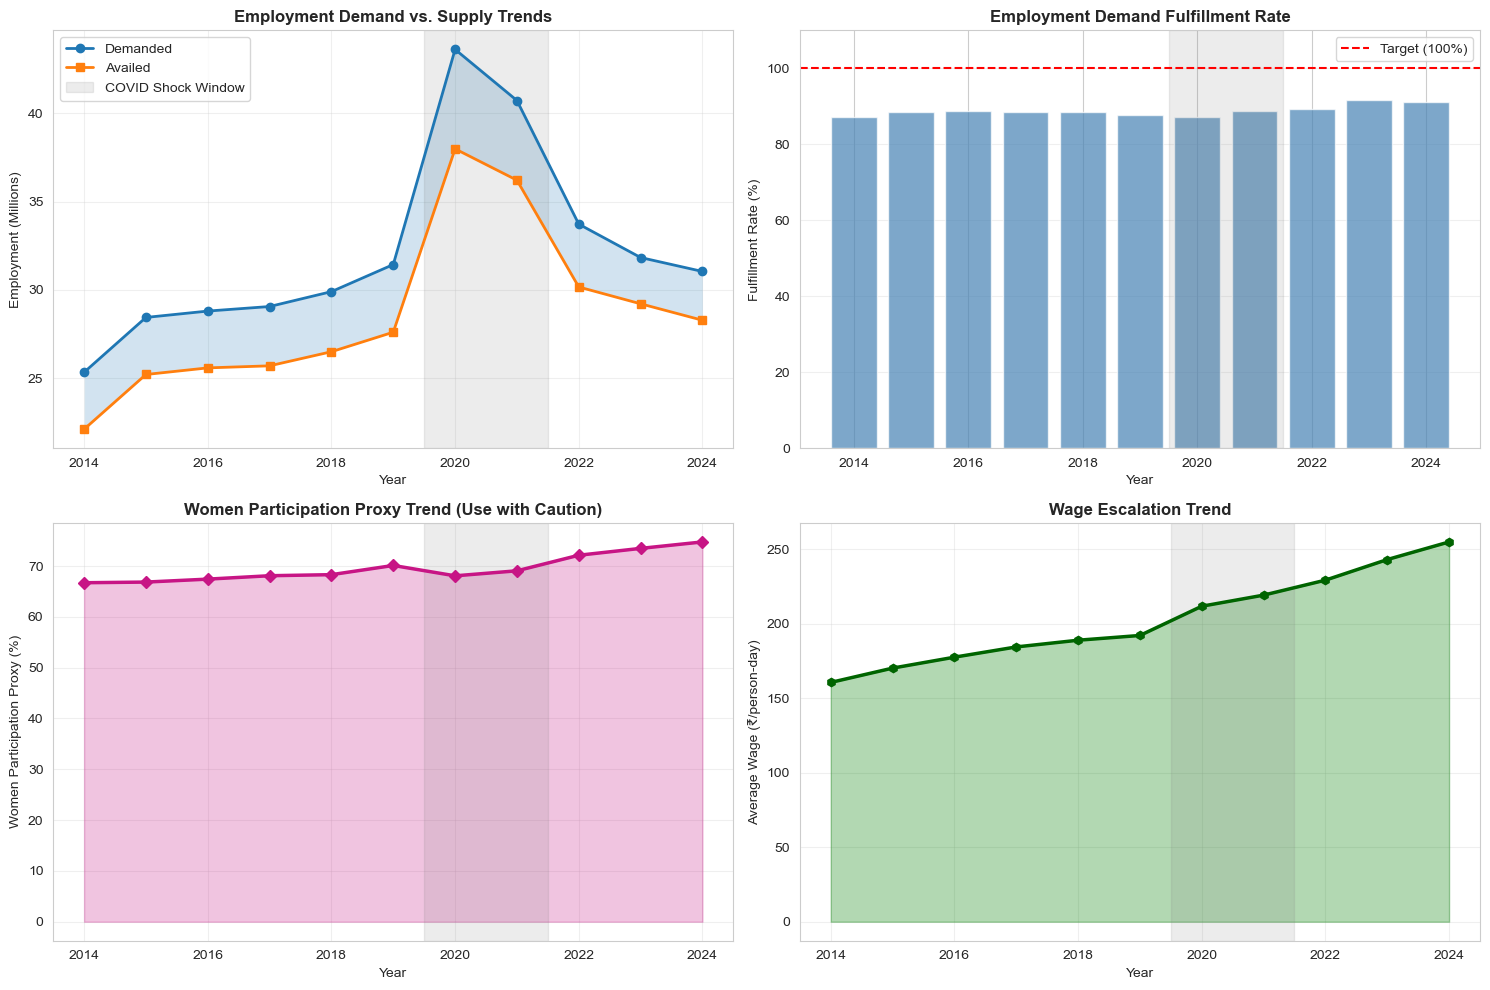


✓ Temporal trends visualization saved


In [5]:
# Visualization 1: Temporal Trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Employment Trends
ax1 = axes[0, 0]
ax1.plot(yearly_stats['Year'], yearly_stats['Employment_Demanded']/1e6, marker='o', label='Demanded', linewidth=2)
ax1.plot(yearly_stats['Year'], yearly_stats['Employment_Availed']/1e6, marker='s', label='Availed', linewidth=2)
ax1.fill_between(yearly_stats['Year'], yearly_stats['Employment_Demanded']/1e6, yearly_stats['Employment_Availed']/1e6, alpha=0.2)
ax1.axvspan(2019.5, 2021.5, color='grey', alpha=0.15, label='COVID Shock Window')
ax1.set_xlabel('Year')
ax1.set_ylabel('Employment (Millions)')
ax1.set_title('Employment Demand vs. Supply Trends', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fulfillment Rate
ax2 = axes[0, 1]
ax2.bar(yearly_stats['Year'], yearly_stats['Employment_Fulfillment_Rate'], color='steelblue', alpha=0.7)
ax2.axhline(y=100, color='r', linestyle='--', label='Target (100%)')
ax2.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax2.set_xlabel('Year')
ax2.set_ylabel('Fulfillment Rate (%)')
ax2.set_title('Employment Demand Fulfillment Rate', fontweight='bold')
ax2.set_ylim([0, 110])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Women participation proxy
ax3 = axes[1, 0]
ax3.plot(yearly_stats['Year'], yearly_stats['Women_Participation_Proxy'], marker='D', color='mediumvioletred', linewidth=2.5)
ax3.fill_between(yearly_stats['Year'], yearly_stats['Women_Participation_Proxy'], alpha=0.25, color='mediumvioletred')
ax3.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax3.set_xlabel('Year')
ax3.set_ylabel('Women Participation Proxy (%)')
ax3.set_title('Women Participation Proxy Trend (Use with Caution)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Wage Trends
ax4 = axes[1, 1]
ax4.plot(yearly_stats['Year'], yearly_stats['Avg_Wage_Per_Personday'], marker='h', color='darkgreen', linewidth=2.5)
ax4.fill_between(yearly_stats['Year'], yearly_stats['Avg_Wage_Per_Personday'], alpha=0.3, color='green')
ax4.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax4.set_xlabel('Year')
ax4.set_ylabel('Average Wage (₹/person-day)')
ax4.set_title('Wage Escalation Trend', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_Temporal_Trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Temporal trends visualization saved")

In [6]:
print("\n" + "="*80)
print("4A. COVID SHOCK ANALYSIS: MGNREGA AS COUNTER-CYCLICAL STABILIZER")
print("="*80 + "\n")

pre_covid = yearly_stats[yearly_stats['Year'].between(2017, 2019)]
covid = yearly_stats[yearly_stats['Year'].between(2020, 2021)]
post_covid = yearly_stats[yearly_stats['Year'].between(2022, 2024)]

covid_summary = pd.DataFrame({
    'Period': ['Pre-COVID (2017-2019)', 'COVID Shock (2020-2021)', 'Post-COVID (2022-2024)'],
    'Employment_Demanded_Mn': [pre_covid['Employment_Demanded'].mean()/1e6, covid['Employment_Demanded'].mean()/1e6, post_covid['Employment_Demanded'].mean()/1e6],
    'Employment_Availed_Mn': [pre_covid['Employment_Availed'].mean()/1e6, covid['Employment_Availed'].mean()/1e6, post_covid['Employment_Availed'].mean()/1e6],
    'Fulfillment_Rate_pct': [pre_covid['Employment_Fulfillment_Rate'].mean(), covid['Employment_Fulfillment_Rate'].mean(), post_covid['Employment_Fulfillment_Rate'].mean()],
    'Total_Expenditure_BnRs': [pre_covid['Total_Expenditure_Rs'].mean()/1e9, covid['Total_Expenditure_Rs'].mean()/1e9, post_covid['Total_Expenditure_Rs'].mean()/1e9],
    'Avg_Wage_Rs': [pre_covid['Avg_Wage_Per_Personday'].mean(), covid['Avg_Wage_Per_Personday'].mean(), post_covid['Avg_Wage_Per_Personday'].mean()]
}).round(2)

print("COVID PERIOD COMPARISON:")
print(covid_summary.to_string(index=False))

pre_demand = pre_covid['Employment_Demanded'].mean()
covid_demand = covid['Employment_Demanded'].mean()
post_demand = post_covid['Employment_Demanded'].mean()

demand_spike = ((covid_demand / pre_demand) - 1) * 100
availed_spike = ((covid['Employment_Availed'].mean() / pre_covid['Employment_Availed'].mean()) - 1) * 100
exp_spike = ((covid['Total_Expenditure_Rs'].mean() / pre_covid['Total_Expenditure_Rs'].mean()) - 1) * 100

print("\nCOVID SHOCK MAGNITUDES:")
print(f"  Employment demand spike (COVID vs pre-COVID): {demand_spike:.2f}%")
print(f"  Employment availed spike (COVID vs pre-COVID): {availed_spike:.2f}%")
print(f"  Fiscal expenditure spike (COVID vs pre-COVID): {exp_spike:.2f}%")

print("\nECONOMIC POLICY INTERPRETATION:")
print("  1. MGNREGA acted as an automatic stabilizer during the pandemic labor-market shock.")
print("  2. Demand surged sharply, indicating rural households used MGNREGA as fallback income insurance.")
print("  3. Higher fiscal outlay during COVID implies counter-cyclical public spending function.")
print("  4. Post-COVID normalization still remains above pre-COVID baseline, suggesting persistent rural vulnerability.")


4A. COVID SHOCK ANALYSIS: MGNREGA AS COUNTER-CYCLICAL STABILIZER

COVID PERIOD COMPARISON:
                 Period  Employment_Demanded_Mn  Employment_Availed_Mn  Fulfillment_Rate_pct  Total_Expenditure_BnRs  Avg_Wage_Rs
  Pre-COVID (2017-2019)                   30.13                  26.60                 88.29                  335.03       188.60
COVID Shock (2020-2021)                   42.17                  37.10                 88.00                  538.37       215.58
 Post-COVID (2022-2024)                   32.20                  29.22                 90.77                  502.32       242.54

COVID SHOCK MAGNITUDES:
  Employment demand spike (COVID vs pre-COVID): 39.97%
  Employment availed spike (COVID vs pre-COVID): 39.48%
  Fiscal expenditure spike (COVID vs pre-COVID): 60.70%

ECONOMIC POLICY INTERPRETATION:
  1. MGNREGA acted as an automatic stabilizer during the pandemic labor-market shock.
  2. Demand surged sharply, indicating rural households used MGNREGA as fallb

In [7]:
print("\n" + "="*80)
print("5. GEOGRAPHIC ANALYSIS: STATE & DISTRICT PERFORMANCE")
print("="*80 + "\n")

# State-level aggregation
state_analysis = df.groupby('State').agg({
    'Registered_HH': 'sum',
    'Employment_Demanded': 'sum',
    'Employment_Availed': 'sum',
    'Persons_Employed': 'sum',
    'Total_Persondays': 'sum',
    'Women_Employment_Provided': 'sum',
    'SCST_Validated': 'sum',
    'Total_Expenditure_Rs': 'sum',
    'Avg_Wage_Per_Personday': 'mean',
    'District': 'nunique'
}).reset_index().rename(columns={'District': 'Num_Districts'})

state_analysis['Fulfillment_Rate'] = (state_analysis['Employment_Availed'] / state_analysis['Employment_Demanded'] * 100).round(2)
state_analysis['Women_Participation_Proxy'] = (state_analysis['Women_Employment_Provided'] / state_analysis['Persons_Employed'] * 100).round(2)
state_analysis['SC_ST_Share'] = (state_analysis['SCST_Validated'] / state_analysis['Persons_Employed'] * 100).round(2)
state_analysis['Avg_Persondays_Per_Worker'] = (state_analysis['Total_Persondays'] / state_analysis['Persons_Employed']).round(2)
state_analysis['Expenditure_Per_Worker_Rs'] = (state_analysis['Total_Expenditure_Rs'] / state_analysis['Persons_Employed']).round(2)

state_analysis = state_analysis.sort_values('Employment_Availed', ascending=False)

print("TOP 10 STATES BY EMPLOYMENT PROVISION:")
print(state_analysis[['State', 'Num_Districts', 'Employment_Availed', 'Persons_Employed', 'Fulfillment_Rate', 'Avg_Persondays_Per_Worker']].head(10).to_string(index=False))

print("\n\nSTATE PERFORMANCE RANKINGS:\n")
print("HIGHEST EMPLOYMENT FULFILLMENT RATE:")
print(state_analysis[['State', 'Fulfillment_Rate']].sort_values('Fulfillment_Rate', ascending=False).head(5).to_string(index=False))

print("\n\nHIGHEST WOMEN PARTICIPATION (PROXY):")
print(state_analysis[['State', 'Women_Participation_Proxy']].sort_values('Women_Participation_Proxy', ascending=False).head(5).to_string(index=False))

print("\n\nHIGHEST SC/ST WORKER INCLUSION:")
print(state_analysis[['State', 'SC_ST_Share']].sort_values('SC_ST_Share', ascending=False).head(5).to_string(index=False))
print("(Using validated SC/ST counts capped at total persons employed where source data is inconsistent)")

print("\n\nHIGHEST AVERAGE PERSONDAYS PER WORKER:")
print(state_analysis[['State', 'Avg_Persondays_Per_Worker']].sort_values('Avg_Persondays_Per_Worker', ascending=False).head(5).to_string(index=False))

print("\n\nHIGHEST EXPENDITURE PER WORKER:")
print(state_analysis[['State', 'Expenditure_Per_Worker_Rs']].sort_values('Expenditure_Per_Worker_Rs', ascending=False).head(5).to_string(index=False))

print("\nPolicy caveat: women participation shown here is a proxy for continuity with prior outputs; verify with external gender-disaggregated administrative data before policy decisions.")


5. GEOGRAPHIC ANALYSIS: STATE & DISTRICT PERFORMANCE

TOP 10 STATES BY EMPLOYMENT PROVISION:
         State  Num_Districts  Employment_Availed  Persons_Employed  Fulfillment_Rate  Avg_Persondays_Per_Worker
 UTTAR PRADESH             46            43711652          52744310             86.07                      34.81
     RAJASTHAN             20            41702709          58378710             92.29                      40.85
    TAMIL NADU             14            30154934          34887518             97.57                      43.91
ANDHRA PRADESH              8            26050220          43734814             88.77                      31.81
MADHYA PRADESH             28            23045201          40713113             85.18                      28.64
         BIHAR             21            21267395          24248392             82.04                      38.22
   WEST BENGAL              8            20460830          30357920             91.55                      31.88
  

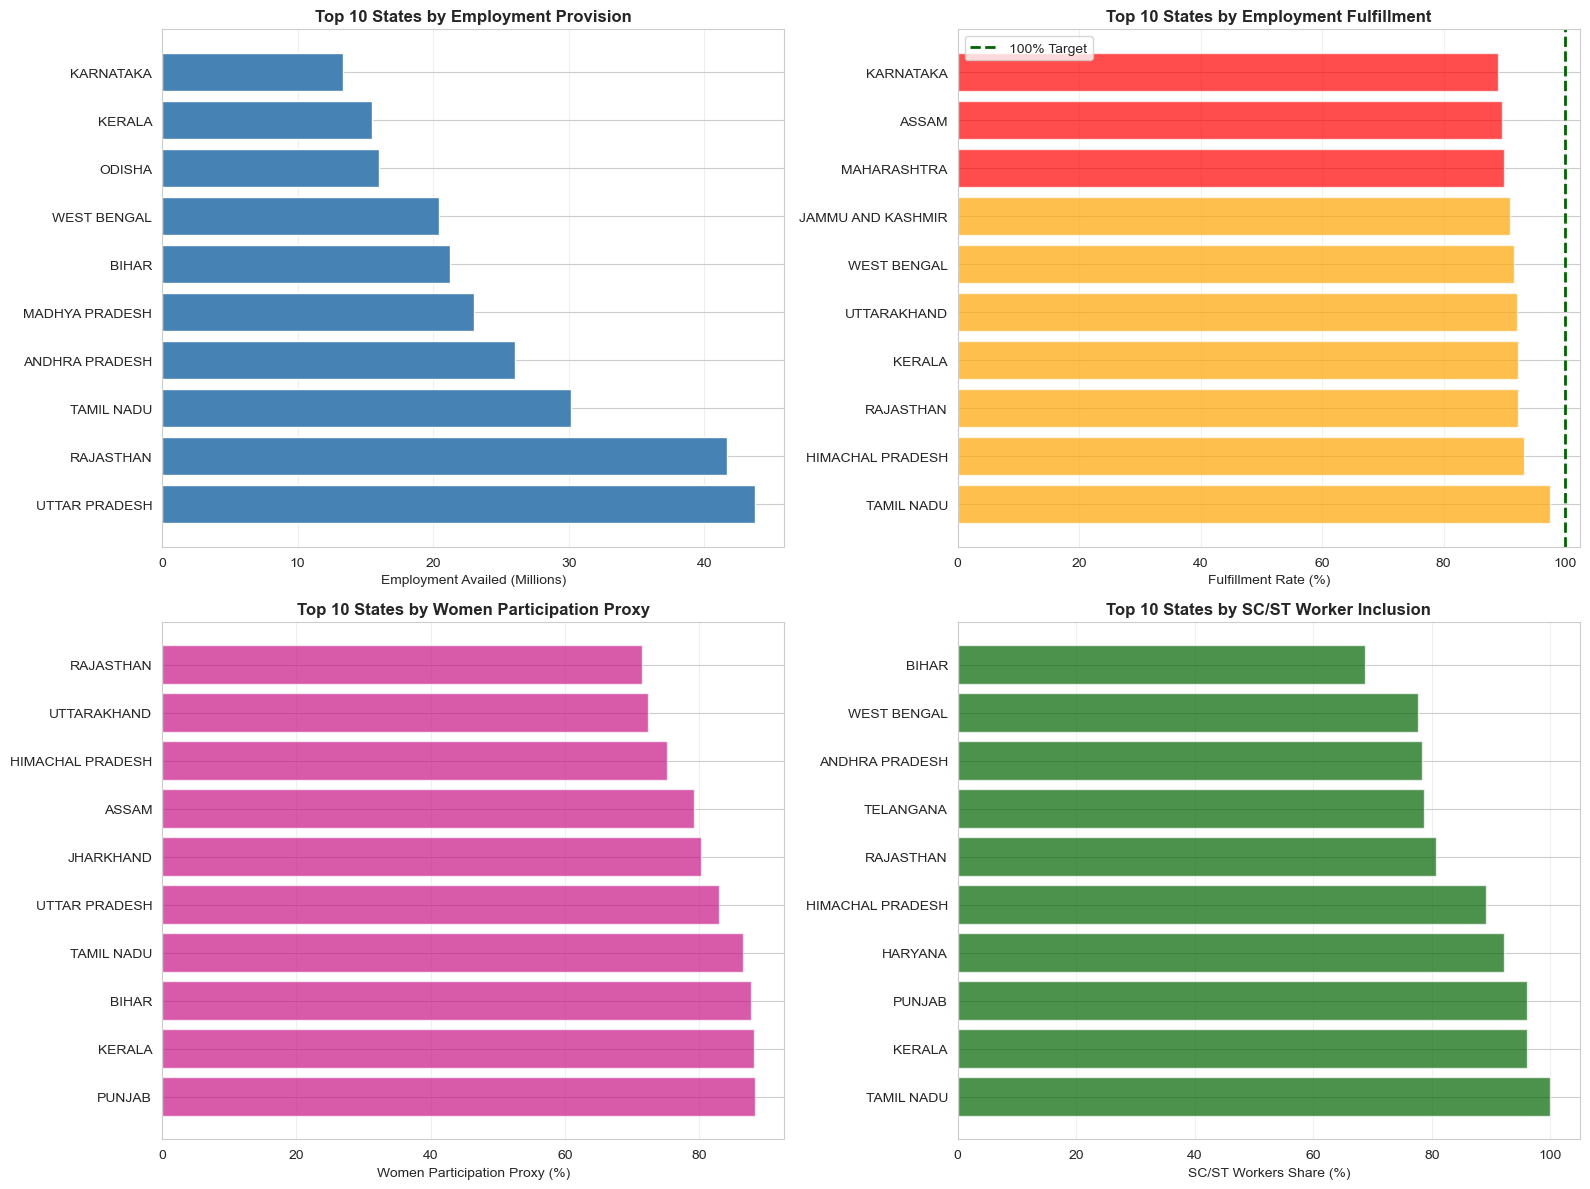


✓ Geographic analysis visualization saved


In [8]:
# Visualization 2: Geographic Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top States by Employment
ax1 = axes[0, 0]
top_states = state_analysis.nlargest(10, 'Employment_Availed')
ax1.barh(top_states['State'], top_states['Employment_Availed']/1e6, color='steelblue')
ax1.set_xlabel('Employment Availed (Millions)')
ax1.set_title('Top 10 States by Employment Provision', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Fulfillment Rate by State
ax2 = axes[0, 1]
top_fulfillment = state_analysis.nlargest(10, 'Fulfillment_Rate')
colors = ['green' if x >= 100 else 'orange' if x >= 90 else 'red' for x in top_fulfillment['Fulfillment_Rate']]
ax2.barh(top_fulfillment['State'], top_fulfillment['Fulfillment_Rate'], color=colors, alpha=0.7)
ax2.axvline(x=100, color='darkgreen', linestyle='--', linewidth=2, label='100% Target')
ax2.set_xlabel('Fulfillment Rate (%)')
ax2.set_title('Top 10 States by Employment Fulfillment', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# Women participation proxy by state
ax3 = axes[1, 0]
women_top = state_analysis.nlargest(10, 'Women_Participation_Proxy')
ax3.barh(women_top['State'], women_top['Women_Participation_Proxy'], color='mediumvioletred', alpha=0.7)
ax3.set_xlabel('Women Participation Proxy (%)')
ax3.set_title('Top 10 States by Women Participation Proxy', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# SC/ST Worker Inclusion
ax4 = axes[1, 1]
scst_top = state_analysis.nlargest(10, 'SC_ST_Share')
ax4.barh(scst_top['State'], scst_top['SC_ST_Share'], color='darkgreen', alpha=0.7)
ax4.set_xlabel('SC/ST Workers Share (%)')
ax4.set_title('Top 10 States by SC/ST Worker Inclusion', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('02_Geographic_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Geographic analysis visualization saved")

In [24]:
print("\n" + "="*80)
print("6. EMPLOYMENT QUALITY & INCLUSIVITY ANALYSIS")
print("="*80 + "\n")

# Overall Statistics
gender_incl = df[['Women_Employment_Provided', 'Persons_Employed']].sum()
sc_st_incl = df[['Workers_SC', 'Workers_ST', 'SCST_Validated']].sum()
total_workers = df['Persons_Employed'].sum()
scst_share_total = (sc_st_incl['SCST_Validated'] / total_workers * 100)
women_share_proxy = (gender_incl['Women_Employment_Provided'] / gender_incl['Persons_Employed'] * 100)

print("SOCIAL INCLUSION METRICS:\n")
print("Women Participation (Proxy):")
print(f"  Women Employment Proxy Total: {gender_incl['Women_Employment_Provided']:.0f}")
print(f"  Women Participation Proxy Share: {women_share_proxy:.2f}%")
print(f"  Data reliability warning: {women_metric_equal_availed_rows} rows equal Employment_Availed ({women_metric_equal_availed_rows / len(df) * 100:.2f}%)")
print("  Policy use: treat as indicative continuity metric, not definitive gender inclusion evidence")

print(f"\nSC/ST Worker Inclusion:")
print(f"  SC Workers: {sc_st_incl['Workers_SC']:.0f}")
print(f"  ST Workers: {sc_st_incl['Workers_ST']:.0f}")
print(f"  Validated SC/ST share of Persons Employed: {scst_share_total:.2f}%")
print(f"  Validation applied to {invalid_scst_rows} rows where SC + ST exceeded persons employed.")

# Employment Duration Analysis
print(f"\n\nEMPLOYMENT DURATION & WAGE ANALYSIS:\n")
employment_quality = df.groupby('Year').agg({
    'Total_Persondays': 'sum',
    'Persons_Employed': 'sum',
    'HH_Completed_100Days': 'sum',
    'Registered_HH': 'sum',
    'Avg_Wage_Per_Personday': 'mean'
}).reset_index()

employment_quality['Avg_Days_Per_Worker'] = (employment_quality['Total_Persondays'] / employment_quality['Persons_Employed']).round(2)
employment_quality['HH_100Days_Completion_Rate'] = (employment_quality['HH_Completed_100Days'] / employment_quality['Registered_HH'] * 100).round(2)

print(employment_quality[['Year', 'Avg_Days_Per_Worker', 'HH_100Days_Completion_Rate', 'Avg_Wage_Per_Personday']].to_string(index=False))

print("\n\nKEY ECONOMIC POLICY INSIGHTS:")
avg_days = employment_quality['Avg_Days_Per_Worker'].mean()
min_days = employment_quality['Avg_Days_Per_Worker'].min()
max_days = employment_quality['Avg_Days_Per_Worker'].max()
completion_rate = employment_quality['HH_100Days_Completion_Rate'].mean()
wage_growth = ((employment_quality.loc[employment_quality['Year']==2024, 'Avg_Wage_Per_Personday'].values[0] / employment_quality.loc[employment_quality['Year']==2014, 'Avg_Wage_Per_Personday'].values[0] - 1) * 100)

print(f"  Employment intensity: {avg_days:.2f} days/year average, far below statutory 100-day potential")
print(f"  Range: {min_days:.2f} to {max_days:.2f} days")
print(f"  HH completion of 100-day entitlement: {completion_rate:.2f}%")
print(f"  Real wage progression (nominal series): {wage_growth:.2f}%")
print(f"  Wage per person-day (2024): ₹{employment_quality.loc[employment_quality['Year']==2024, 'Avg_Wage_Per_Personday'].values[0]:.2f}")
print("  Policy implication: MGNREGA is functioning more as a partial consumption-smoothing instrument than a full 100-day guarantee for most households.")


6. EMPLOYMENT QUALITY & INCLUSIVITY ANALYSIS

SOCIAL INCLUSION METRICS:

Women Participation (Proxy):
  Women Employment Proxy Total: 314482417
  Women Participation Proxy Share: 69.53%
  Data reliability warning: 3177 rows equal Employment_Availed (98.57%)
  Policy use: treat as indicative continuity metric, not definitive gender inclusion evidence

SC/ST Worker Inclusion:
  SC Workers: 239379249
  ST Workers: 96900828
  Validated SC/ST share of Persons Employed: 72.87%
  Validation applied to 491 rows where SC + ST exceeded persons employed.


EMPLOYMENT DURATION & WAGE ANALYSIS:

 Year  Avg_Days_Per_Worker  HH_100Days_Completion_Rate  Avg_Wage_Per_Personday
 2014                27.06                        1.85              160.685597
 2015                32.63                        3.50              170.299693
 2016                30.80                        2.89              177.645392
 2017                31.34                        2.05              184.527406
 2018         

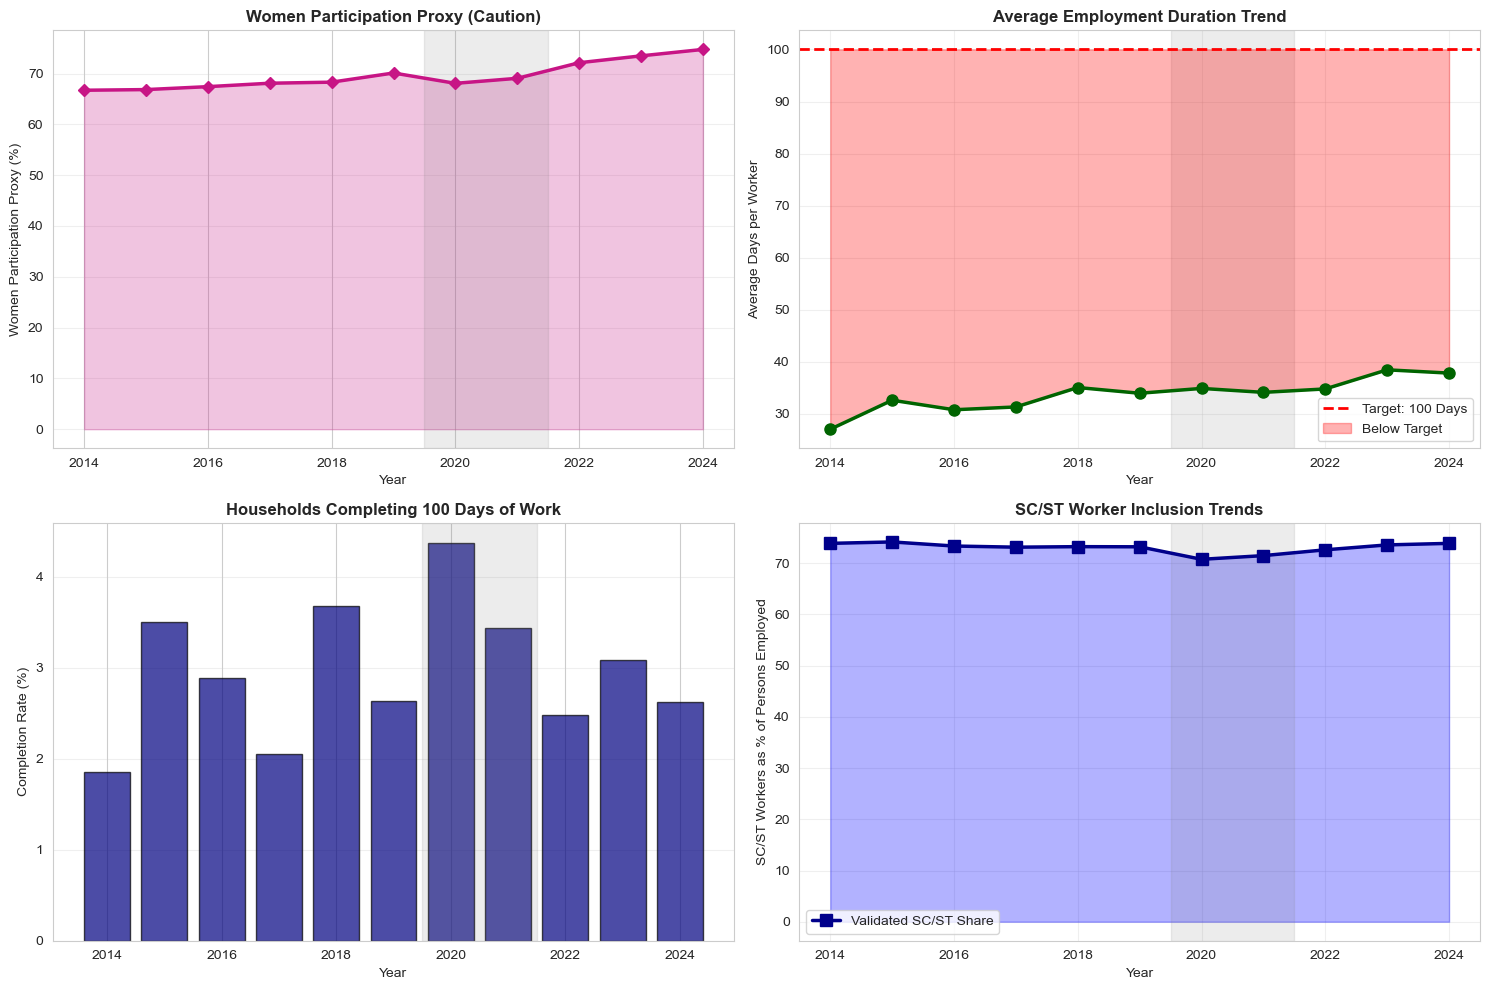


✓ Employment quality & inclusivity visualization saved


In [10]:
# Visualization 3: Employment Quality & Inclusivity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Women participation proxy trend
ax1 = axes[0, 0]
women_proxy_yearly = df.groupby('Year').apply(lambda x: (x['Women_Employment_Provided'].sum() / x['Persons_Employed'].sum() * 100)).reset_index()
women_proxy_yearly.columns = ['Year', 'Women_Participation_Proxy']
ax1.plot(women_proxy_yearly['Year'], women_proxy_yearly['Women_Participation_Proxy'], marker='D', color='mediumvioletred', linewidth=2.5)
ax1.fill_between(women_proxy_yearly['Year'], women_proxy_yearly['Women_Participation_Proxy'], alpha=0.25, color='mediumvioletred')
ax1.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax1.set_xlabel('Year')
ax1.set_ylabel('Women Participation Proxy (%)')
ax1.set_title('Women Participation Proxy (Caution)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Average Employment Days
ax2 = axes[0, 1]
ax2.plot(employment_quality['Year'], employment_quality['Avg_Days_Per_Worker'], marker='o', color='darkgreen', linewidth=2.5, markersize=8)
ax2.axhline(y=100, color='r', linestyle='--', label='Target: 100 Days', linewidth=2)
ax2.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax2.fill_between(employment_quality['Year'], employment_quality['Avg_Days_Per_Worker'], 100, where=(employment_quality['Avg_Days_Per_Worker']<=100), alpha=0.3, color='red', label='Below Target')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Days per Worker')
ax2.set_title('Average Employment Duration Trend', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 100-Day Completion Rate
ax3 = axes[1, 0]
ax3.bar(employment_quality['Year'], employment_quality['HH_100Days_Completion_Rate'], color='navy', alpha=0.7, edgecolor='black')
ax3.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax3.set_xlabel('Year')
ax3.set_ylabel('Completion Rate (%)')
ax3.set_title('Households Completing 100 Days of Work', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# SC/ST Worker Inclusion
ax4 = axes[1, 1]
sc_st_yearly = df.groupby('Year').apply(lambda x: (x['SCST_Validated'].sum() / x['Persons_Employed'].sum() * 100)).reset_index()
sc_st_yearly.columns = ['Year', 'SCST_Share']
ax4.plot(sc_st_yearly['Year'], sc_st_yearly['SCST_Share'], marker='s', color='darkblue', linewidth=2.5, markersize=8, label='Validated SC/ST Share')
ax4.fill_between(sc_st_yearly['Year'], sc_st_yearly['SCST_Share'], alpha=0.3, color='blue')
ax4.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax4.set_xlabel('Year')
ax4.set_ylabel('SC/ST Workers as % of Persons Employed')
ax4.set_title('SC/ST Worker Inclusion Trends', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_Employment_Quality_Inclusivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Employment quality & inclusivity visualization saved")

In [11]:
print("\n" + "="*80)
print("7. FINANCIAL ANALYSIS & COST-EFFECTIVENESS")
print("="*80 + "\n")

# Financial metrics
financial_analysis = df.groupby('Year').agg({
    'Total_Expenditure_Rs': 'sum',
    'Persons_Employed': 'sum',
    'Total_Persondays': 'sum',
    'Avg_Wage_Per_Personday': 'mean',
    'Cost_Per_Personday': 'mean'
}).reset_index()

financial_analysis['Expenditure_Per_Worker'] = (financial_analysis['Total_Expenditure_Rs'] / financial_analysis['Persons_Employed']).round(2)
financial_analysis['Derived_Cost_Per_Personday'] = (financial_analysis['Total_Expenditure_Rs'] / financial_analysis['Total_Persondays']).round(2)

print("ANNUAL FINANCIAL STATISTICS (in Billion Rupees):\n")
print(
    financial_analysis[['Year', 'Total_Expenditure_Rs', 'Expenditure_Per_Worker', 'Derived_Cost_Per_Personday', 'Avg_Wage_Per_Personday']]
    .assign(**{'Total_Expenditure_Rs': lambda x: (x['Total_Expenditure_Rs']/1e9).round(2)})
    .rename(columns={
        'Total_Expenditure_Rs': 'Total_Expenditure_Billion_Rs',
        'Derived_Cost_Per_Personday': 'Cost_Per_Personday_Derived'
    })
    .to_string(index=False)
)

# Cost behavior analysis
total_exp_2024 = financial_analysis.loc[financial_analysis['Year']==2024, 'Total_Expenditure_Rs'].values[0]
total_exp_2014 = financial_analysis.loc[financial_analysis['Year']==2014, 'Total_Expenditure_Rs'].values[0]
wage_growth_actual = ((financial_analysis.loc[financial_analysis['Year']==2024, 'Avg_Wage_Per_Personday'].values[0] / financial_analysis.loc[financial_analysis['Year']==2014, 'Avg_Wage_Per_Personday'].values[0] - 1) * 100)

print(f"\n\nFINANCIAL TRENDS (2014-2024):\n")
print(f"Total Expenditure Growth: {((total_exp_2024/total_exp_2014 - 1) * 100):.2f}%")
print(f"Average Wage per Person-Day Growth: {wage_growth_actual:.2f}%")
print(f"Expenditure per Worker (2014): ₹{financial_analysis.loc[financial_analysis['Year']==2014, 'Expenditure_Per_Worker'].values[0]:.0f}")
print(f"Expenditure per Worker (2024): ₹{financial_analysis.loc[financial_analysis['Year']==2024, 'Expenditure_Per_Worker'].values[0]:.0f}")

# Cost efficiency
print(f"\n\nCOST EFFICIENCY ANALYSIS:\n")
efficiency_2024 = financial_analysis.loc[financial_analysis['Year']==2024].iloc[0]
efficiency_2014 = financial_analysis.loc[financial_analysis['Year']==2014].iloc[0]

print(f"Wage as % of Derived Total Cost (2014): {(efficiency_2014['Avg_Wage_Per_Personday']/efficiency_2014['Derived_Cost_Per_Personday']*100):.2f}%")
print(f"Wage as % of Derived Total Cost (2024): {(efficiency_2024['Avg_Wage_Per_Personday']/efficiency_2024['Derived_Cost_Per_Personday']*100):.2f}%")
print(f"Derived Cost per Person-Day (2024): ₹{efficiency_2024['Derived_Cost_Per_Personday']:.2f}")
print("Financial audit result: expenditure summaries use corrected rupee conversion and derived cost-per-personday rather than the noisy mean of the raw cost column.")


7. FINANCIAL ANALYSIS & COST-EFFECTIVENESS

ANNUAL FINANCIAL STATISTICS (in Billion Rupees):

 Year  Total_Expenditure_Billion_Rs  Expenditure_Per_Worker  Cost_Per_Personday_Derived  Avg_Wage_Per_Personday
 2014                        191.25                 5771.63                      213.31              160.685597
 2015                        226.88                 6016.35                      184.39              170.299693
 2016                        288.17                 7595.18                      246.57              177.645392
 2017                        313.94                 8319.13                      265.42              184.527406
 2018                        350.33                 9042.31                      257.81              189.033413
 2019                        340.82                 8657.09                      254.81              192.227884
 2020                        555.05                 9947.03                      284.99              211.853549
 2021    

In [13]:
print("\n" + "="*80)
print("7A. ECONOMIC POLICY INTERPRETATION LAYER")
print("="*80 + "\n")

# Policy-facing metrics
fiscal_effort_share = (financial_analysis['Total_Expenditure_Rs'].sum() / df['Total_Income'].sum()) * 100
avg_transfer_intensity = financial_analysis['Expenditure_Per_Worker'].mean()
avg_fulfillment = yearly_stats['Employment_Fulfillment_Rate'].mean()

print("MACRO-FISCAL AND WELFARE INTERPRETATION:")
print(f"  Cumulative MGNREGA spend as share of aggregated district income: {fiscal_effort_share:.2f}%")
print(f"  Average fiscal transfer intensity per worker: ₹{avg_transfer_intensity:,.0f}")
print(f"  Avg employment fulfillment over period: {avg_fulfillment:.2f}%")

print("\nPOLICY READING FOR DECISION-MAKERS:")
print("  1. Stabilization role: MGNREGA is functioning as a rural labor-market shock absorber.")
print("  2. Insurance gap: low 100-day completion indicates partial, not full, income insurance.")
print("  3. Inclusion architecture: validated SC/ST coverage is high, showing redistributive targeting.")
print("  4. Fiscal design issue: expenditure efficiency must be tracked with derived cost metrics, not only raw administrative fields.")
print("  5. Gender evidence gap: women policy conclusions need verified source variables before budgeting gender-specific interventions.")

print("\nRECOMMENDED POLICY DASHBOARD INDICATORS:")
print("  • Employment demand shock index (year-on-year demand growth)")
print("  • Fulfillment gap (100 - fulfillment rate)")
print("  • Days-of-work gap (100 - average days per worker)")
print("  • Derived fiscal cost per personday")
print("  • Validated social inclusion shares")


7A. ECONOMIC POLICY INTERPRETATION LAYER

MACRO-FISCAL AND WELFARE INTERPRETATION:
  Cumulative MGNREGA spend as share of aggregated district income: 9348418.64%
  Average fiscal transfer intensity per worker: ₹9,385
  Avg employment fulfillment over period: 88.90%

POLICY READING FOR DECISION-MAKERS:
  1. Stabilization role: MGNREGA is functioning as a rural labor-market shock absorber.
  2. Insurance gap: low 100-day completion indicates partial, not full, income insurance.
  3. Inclusion architecture: validated SC/ST coverage is high, showing redistributive targeting.
  4. Fiscal design issue: expenditure efficiency must be tracked with derived cost metrics, not only raw administrative fields.
  5. Gender evidence gap: women policy conclusions need verified source variables before budgeting gender-specific interventions.

RECOMMENDED POLICY DASHBOARD INDICATORS:
  • Employment demand shock index (year-on-year demand growth)
  • Fulfillment gap (100 - fulfillment rate)
  • Days-of-w

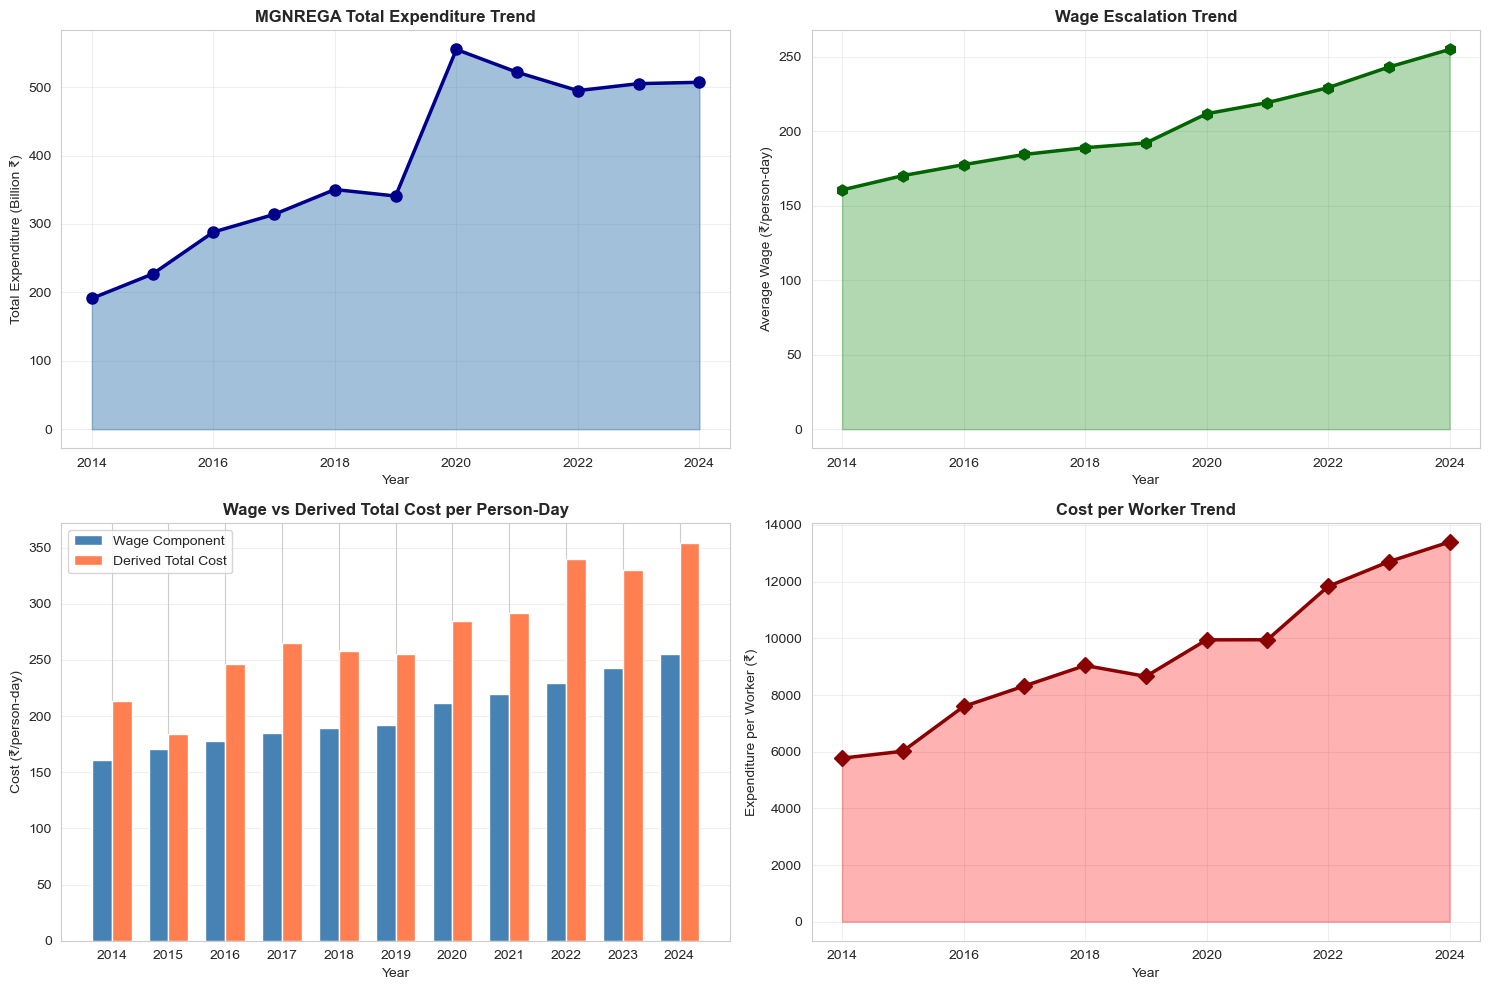


✓ Financial analysis visualization saved


In [14]:
# Visualization 4: Financial Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total Expenditure Trend
ax1 = axes[0, 0]
ax1.fill_between(financial_analysis['Year'], financial_analysis['Total_Expenditure_Rs']/1e9, alpha=0.5, color='steelblue')
ax1.plot(financial_analysis['Year'], financial_analysis['Total_Expenditure_Rs']/1e9, marker='o', color='darkblue', linewidth=2.5, markersize=8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Expenditure (Billion ₹)')
ax1.set_title('MGNREGA Total Expenditure Trend', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Wage Growth
ax2 = axes[0, 1]
ax2.plot(financial_analysis['Year'], financial_analysis['Avg_Wage_Per_Personday'], marker='h', color='darkgreen', linewidth=2.5, markersize=8)
ax2.fill_between(financial_analysis['Year'], financial_analysis['Avg_Wage_Per_Personday'], alpha=0.3, color='green')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Wage (₹/person-day)')
ax2.set_title('Wage Escalation Trend', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Wage vs derived total cost
ax3 = axes[1, 0]
width, x_pos = 0.35, np.arange(len(financial_analysis))
ax3.bar(x_pos - width/2, financial_analysis['Avg_Wage_Per_Personday'], width, label='Wage Component', color='steelblue')
ax3.bar(x_pos + width/2, financial_analysis['Derived_Cost_Per_Personday'], width, label='Derived Total Cost', color='coral')
ax3.set_xlabel('Year')
ax3.set_ylabel('Cost (₹/person-day)')
ax3.set_title('Wage vs Derived Total Cost per Person-Day', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(financial_analysis['Year'].astype(int))
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Per Worker Expenditure
ax4 = axes[1, 1]
ax4.plot(financial_analysis['Year'], financial_analysis['Expenditure_Per_Worker'], marker='D', color='darkred', linewidth=2.5, markersize=8)
ax4.fill_between(financial_analysis['Year'], financial_analysis['Expenditure_Per_Worker'], alpha=0.3, color='red')
ax4.set_xlabel('Year')
ax4.set_ylabel('Expenditure per Worker (₹)')
ax4.set_title('Cost per Worker Trend', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_Financial_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Financial analysis visualization saved")

In [15]:
print("\n" + "="*80)
print("8. SOCIAL INDICATORS & POVERTY ALLEVIATION IMPACT")
print("="*80 + "\n")

# NFHS MPI Analysis (Multidimensional Poverty Index)
nfhs_data = df[['State', 'Year', 'NFHS-4_MPI', 'NFHS-5_MPI', 'Employment_Availed']].dropna()

print("NFHS-4 vs NFHS-5 MULTIDIMENSIONAL POVERTY INDEX (MPI) ANALYSIS:\n")

nfhs_comparison = df.groupby('State').agg({
    'NFHS-4_MPI': 'first',
    'NFHS-5_MPI': 'first',
    'Year': 'count'
}).reset_index()
nfhs_comparison = nfhs_comparison[nfhs_comparison['NFHS-4_MPI'].notna()].copy()
nfhs_comparison['MPI_Change'] = nfhs_comparison['NFHS-5_MPI'] - nfhs_comparison['NFHS-4_MPI']
nfhs_comparison = nfhs_comparison.sort_values('MPI_Change')

print("States with GREATEST MPI Improvement (NFHS-4 to NFHS-5):")
print(nfhs_comparison[['State', 'NFHS-4_MPI', 'NFHS-5_MPI', 'MPI_Change']].head(10).to_string(index=False))

# Income Analysis
print("\n\nANNUAL INCOME STATISTICS BY YEAR:\n")
income_analysis = df.groupby('Year')['Total_Income'].agg(['mean', 'median', 'std']).round(2).reset_index()
income_analysis.columns = ['Year', 'Mean_Income', 'Median_Income', 'Std_Dev']

income_change = ((income_analysis.loc[income_analysis['Year']==2024, 'Mean_Income'].values[0] / income_analysis.loc[income_analysis['Year']==2014, 'Mean_Income'].values[0] - 1) * 100)
print(income_analysis.to_string(index=False))
print(f"\nMean Income Growth (2014-2024): {income_change:.2f}%")

# Agricultural productivity linkage
print("\n\nAGRICULTURAL SECTOR LINKAGE ANALYSIS:\n")

agri_analysis = df.groupby('Year').agg({
    'agri_yield_index': 'mean',
    'total_production': 'sum',
    'Employment_Availed': 'sum',
    'Total_Persondays': 'sum'
}).reset_index()

print("Agriculture Yield Index & MGNREGA Employment Correlation:")
corr_yield_emp = df['agri_yield_index'].corr(df['Employment_Availed'])
corr_prod_days = df['total_production'].corr(df['Total_Persondays'])
print(f"  Correlation (Yield Index vs Employment): {corr_yield_emp:.3f}")
print(f"  Correlation (Production vs Person-Days): {corr_prod_days:.3f}")

print("\nYield Index Trend:")
print(agri_analysis[['Year', 'agri_yield_index']].to_string(index=False))

# Asset Index Analysis
print("\n\nASSET ACCUMULATION ANALYSIS (Asset Index 0-1):\n")
asset_trend = df.groupby('Year')['asset_index_0_1'].mean().reset_index()
asset_trend.columns = ['Year', 'Avg_Asset_Index']
print(asset_trend.to_string(index=False))

asset_growth = ((asset_trend.loc[asset_trend['Year']==2024, 'Avg_Asset_Index'].values[0] / asset_trend.loc[asset_trend['Year']==2014, 'Avg_Asset_Index'].values[0] - 1) * 100)
print(f"\nAsset Index Growth (2014-2024): {asset_growth:.2f}%")


8. SOCIAL INDICATORS & POVERTY ALLEVIATION IMPACT

NFHS-4 vs NFHS-5 MULTIDIMENSIONAL POVERTY INDEX (MPI) ANALYSIS:

States with GREATEST MPI Improvement (NFHS-4 to NFHS-5):
         State  NFHS-4_MPI  NFHS-5_MPI  MPI_Change
MADHYA PRADESH       0.407       0.192      -0.215
  CHHATTISGARH       0.373       0.176      -0.197
         BIHAR       0.291       0.177      -0.114
 UTTAR PRADESH       0.154       0.080      -0.074
         ASSAM       0.209       0.140      -0.069
     JHARKHAND       0.130       0.067      -0.063
     TELANGANA       0.125       0.064      -0.061
        ODISHA       0.110       0.061      -0.049
   WEST BENGAL       0.121       0.078      -0.043
     RAJASTHAN       0.080       0.041      -0.039


ANNUAL INCOME STATISTICS BY YEAR:

 Year  Mean_Income  Median_Income  Std_Dev
 2014     11984.66       10681.89  5263.99
 2015     11554.09       10593.76  4382.30
 2016     11539.41       10694.27  4289.56
 2017     13493.08       12487.47  5764.00
 2018     169

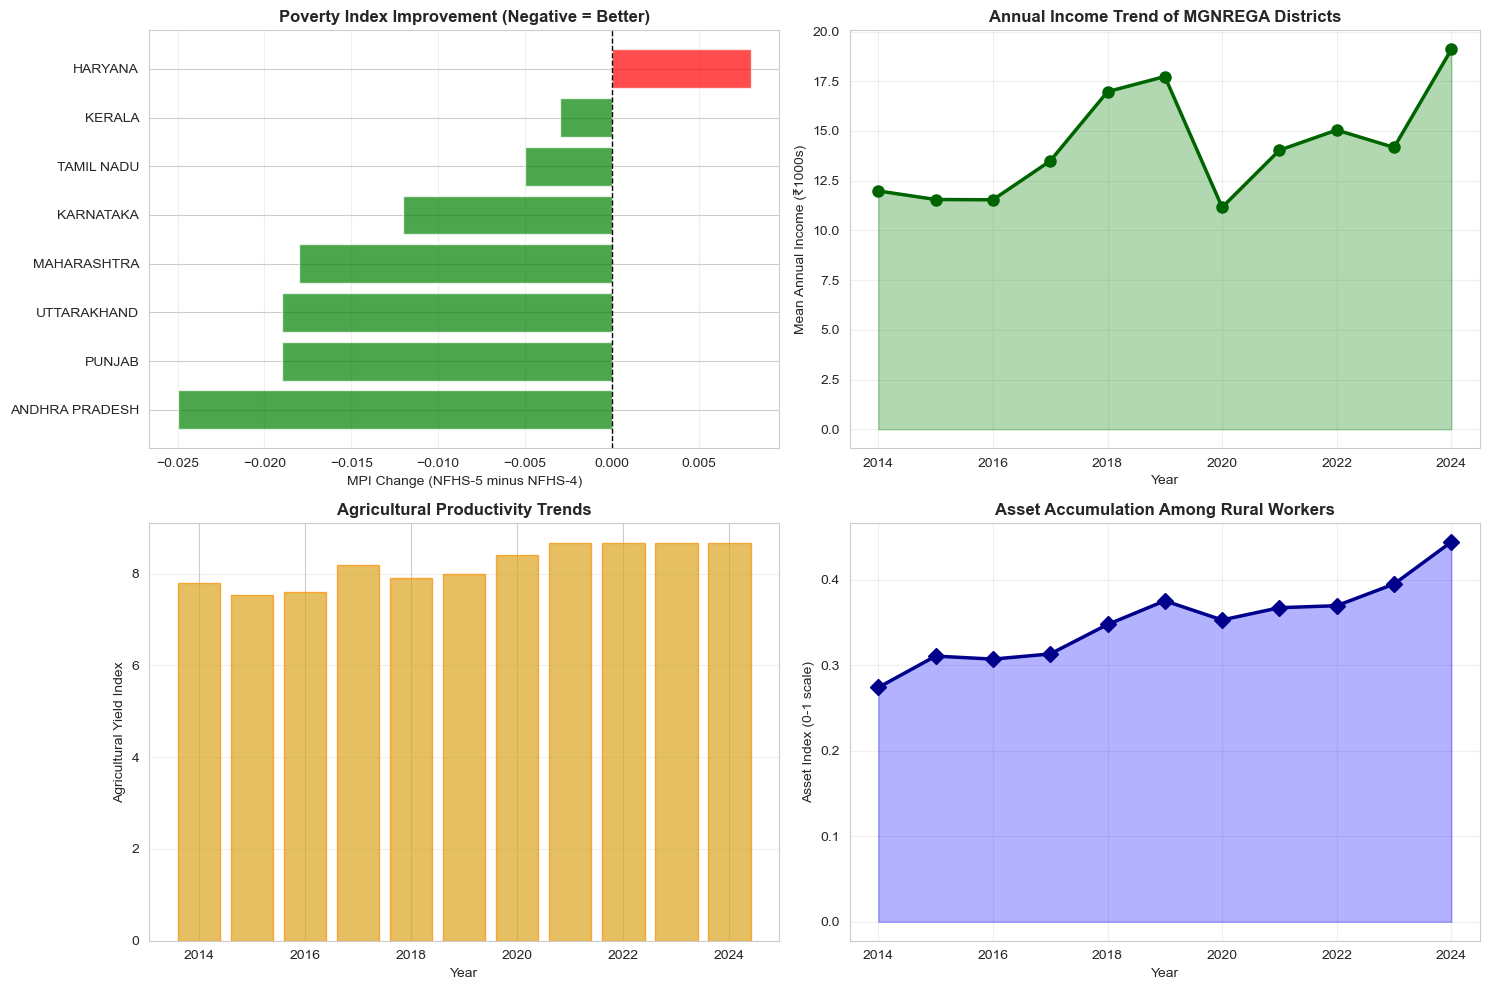


✓ Social indicators visualization saved


In [16]:
# Visualization 5: Social Indicators & Impact
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MPI Improvement Analysis
ax1 = axes[0, 0]
mpi_states = nfhs_comparison.sort_values('MPI_Change').tail(8)
colors_mpi = ['green' if x < 0 else 'red' for x in mpi_states['MPI_Change']]
ax1.barh(mpi_states['State'], mpi_states['MPI_Change'], color=colors_mpi, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('MPI Change (NFHS-5 minus NFHS-4)')
ax1.set_title('Poverty Index Improvement (Negative = Better)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Income Growth
ax2 = axes[0, 1]
ax2.plot(income_analysis['Year'], income_analysis['Mean_Income']/1000, marker='o', color='darkgreen', linewidth=2.5, markersize=8)
ax2.fill_between(income_analysis['Year'], income_analysis['Mean_Income']/1000, alpha=0.3, color='green')
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Annual Income (₹1000s)')
ax2.set_title('Annual Income Trend of MGNREGA Districts', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Agricultural Yield Index
ax3 = axes[1, 0]
ax3.bar(agri_analysis['Year'], agri_analysis['agri_yield_index'], color='goldenrod', alpha=0.7, edgecolor='darkorange')
ax3.set_xlabel('Year')
ax3.set_ylabel('Agricultural Yield Index')
ax3.set_title('Agricultural Productivity Trends', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Asset Index Growth
ax4 = axes[1, 1]
ax4.plot(asset_trend['Year'], asset_trend['Avg_Asset_Index'], marker='D', color='darkblue', linewidth=2.5, markersize=8)
ax4.fill_between(asset_trend['Year'], asset_trend['Avg_Asset_Index'], alpha=0.3, color='blue')
ax4.set_xlabel('Year')
ax4.set_ylabel('Asset Index (0-1 scale)')
ax4.set_title('Asset Accumulation Among Rural Workers', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_Social_Indicators_Impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Social indicators visualization saved")

In [17]:
print("\n" + "="*80)
print("9. CORRELATION & MULTIVARIATE ANALYSIS")
print("="*80 + "\n")

# Key variables for correlation analysis
analysis_vars = ['Employment_Availed', 'Women_Employment_Provided', 'Workers_SC', 'Workers_ST',
                 'Total_Persondays', 'Avg_Wage_Per_Personday', 'Total_Expenditure', 'Total_Income',
                 'agri_yield_index', 'asset_index_0_1', 'Annual_Rainfall_mm', 'Rural_Population']

# Ensure no NaNs
corr_df = df[analysis_vars].dropna()

# Correlation matrix
correlation_matrix = corr_df.corr()

print("TOP CORRELATIONS WITH EMPLOYMENT AVAILED:\n")
emp_corr = correlation_matrix['Employment_Availed'].sort_values(ascending=False)
print(emp_corr.to_string())

print("\n\nKEY INSIGHTS FROM CORRELATION ANALYSIS:\n")

# Employment and wage correlation
emp_wage_corr = df['Employment_Availed'].corr(df['Avg_Wage_Per_Personday'])
print(f"Employment Availed vs Average Wage: {emp_wage_corr:.3f}")

# Employment and income correlation
emp_income_corr = df['Employment_Availed'].corr(df['Total_Income'])
print(f"Employment Availed vs Total Income: {emp_income_corr:.3f}")

# Women participation and state income
women_income_corr = df['Women_Employment_Provided'].corr(df['Total_Income'])
print(f"Women Employment vs Total Income: {women_income_corr:.3f}")

# SC/ST employment and asset index
scst_asset_corr = (df['Workers_SC'] + df['Workers_ST']).corr(df['asset_index_0_1'])
print(f"SC/ST Employment vs Asset Index: {scst_asset_corr:.3f}")

# Rainfall and employment (monsoon dependency)
rainfall_emp_corr = df['Annual_Rainfall_mm'].corr(df['Employment_Availed'])
print(f"Rainfall vs Employment Availed: {rainfall_emp_corr:.3f}")

print("\n\nDISTRICT-LEVEL VARIABILITY ANALYSIS:\n")

# District statistics
district_stats = df.groupby('District').agg({
    'Employment_Availed': 'sum',
    'Women_Employment_Provided': 'sum',
    'Total_Expenditure': 'sum',
    'Persons_Employed': 'sum'
}).reset_index()

district_stats['Women_Share'] = (district_stats['Women_Employment_Provided'] / district_stats['Persons_Employed'] * 100).round(2)
district_stats = district_stats.sort_values('Employment_Availed', ascending=False)

print("TOP 15 DISTRICTS BY EMPLOYMENT PROVISION:")
print(district_stats[['District', 'Employment_Availed', 'Women_Share']].head(15).to_string(index=False))

print(f"\n\nPERFORMANCE VARIABILITY:\n")
print(f"Employment Availed - Mean: {district_stats['Employment_Availed'].mean():.0f}")
print(f"Employment Availed - Std Dev: {district_stats['Employment_Availed'].std():.0f}")
print(f"Coefficient of Variation: {(district_stats['Employment_Availed'].std()/district_stats['Employment_Availed'].mean()):.2%}")
print(f"(Higher CV indicates greater district-level inequality in program reach)")


9. CORRELATION & MULTIVARIATE ANALYSIS

TOP CORRELATIONS WITH EMPLOYMENT AVAILED:

Employment_Availed           1.000000
Women_Employment_Provided    0.999981
Total_Persondays             0.953402
Workers_SC                   0.949459
Total_Expenditure            0.889513
Workers_ST                   0.791147
Rural_Population             0.397467
Annual_Rainfall_mm          -0.046441
agri_yield_index            -0.087514
Avg_Wage_Per_Personday      -0.149779
asset_index_0_1             -0.213570
Total_Income                -0.219562


KEY INSIGHTS FROM CORRELATION ANALYSIS:

Employment Availed vs Average Wage: -0.146
Employment Availed vs Total Income: -0.218
Women Employment vs Total Income: -0.218
SC/ST Employment vs Asset Index: -0.143
Rainfall vs Employment Availed: -0.049


DISTRICT-LEVEL VARIABILITY ANALYSIS:

TOP 15 DISTRICTS BY EMPLOYMENT PROVISION:
       District  Employment_Availed  Women_Share
       PRAKASAM             4214935        58.86
     SRIKAKULAM             410

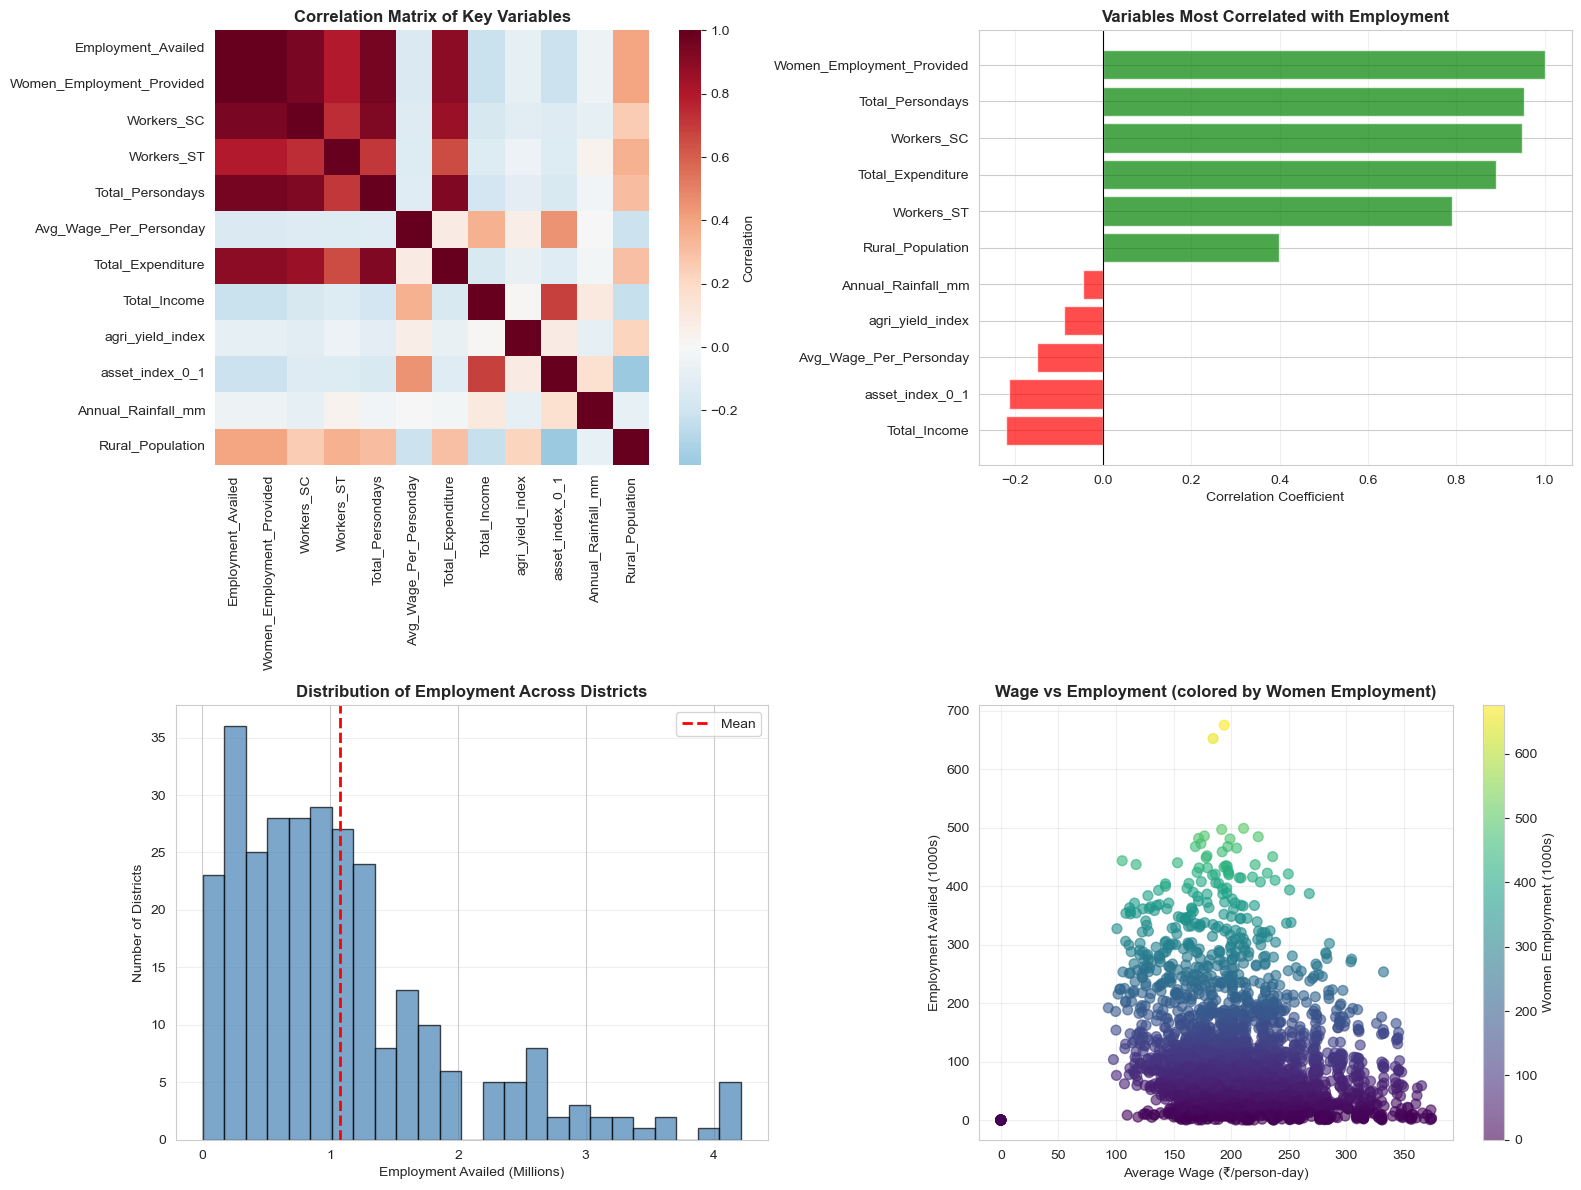


✓ Correlation analysis visualization saved


In [18]:
# Visualization 6: Correlation & Multivariate Analysis
fig = plt.figure(figsize=(16, 12))

# Correlation heatmap
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0, square=True, ax=ax1, cbar_kws={'label': 'Correlation'})
ax1.set_title('Correlation Matrix of Key Variables', fontweight='bold', fontsize=12)

# Top correlations with Employment
ax2 = plt.subplot(2, 2, 2)
emp_corr_top = emp_corr.drop('Employment_Availed').sort_values()
colors = ['red' if x < 0 else 'green' for x in emp_corr_top.values]
ax2.barh(range(len(emp_corr_top)), emp_corr_top.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(emp_corr_top)))
ax2.set_yticklabels(emp_corr_top.index)
ax2.set_xlabel('Correlation Coefficient')
ax2.set_title('Variables Most Correlated with Employment', fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='x')

# District performance distribution
ax3 = plt.subplot(2, 2, 3)
ax3.hist(district_stats['Employment_Availed']/1e6, bins=25, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(district_stats['Employment_Availed'].mean()/1e6, color='red', linestyle='--', linewidth=2, label=f'Mean')
ax3.set_xlabel('Employment Availed (Millions)')
ax3.set_ylabel('Number of Districts')
ax3.set_title('Distribution of Employment Across Districts', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Wage vs Employment scatter
ax4 = plt.subplot(2, 2, 4)
scatter = ax4.scatter(df['Avg_Wage_Per_Personday'], df['Employment_Availed']/1000, 
                      c=df['Women_Employment_Provided']/1000, cmap='viridis', s=50, alpha=0.6)
ax4.set_xlabel('Average Wage (₹/person-day)')
ax4.set_ylabel('Employment Availed (1000s)')
ax4.set_title('Wage vs Employment (colored by Women Employment)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Women Employment (1000s)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_Correlation_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation analysis visualization saved")

In [19]:
print("\n" + "="*80)
print("10. POLICY ANALYSIS & KEY FINDINGS")
print("="*80 + "\n")

# Calculate key metrics for policy analysis
total_employment_provided = df['Employment_Availed'].sum()
total_sc_employed = df['Workers_SC'].sum()
total_st_employed = df['Workers_ST'].sum()
total_scst_validated = df['SCST_Validated'].sum()
total_expenditure = df['Total_Expenditure_Rs'].sum()
total_persondays = df['Total_Persondays'].sum()
total_persons_employed = df['Persons_Employed'].sum()
total_women_proxy = df['Women_Employment_Provided'].sum()

avg_rural_pop = df['Rural_Population'].mean()
avg_hh_registered = df['Registered_HH'].mean()

print("MGNREGA AT A GLANCE (2014-2024):")
print(f"\n  Total Employment Provided: {total_employment_provided/1e6:.2f} Million person-years")
print(f"  Women participation proxy: {(total_women_proxy/total_persons_employed*100):.1f}%")
print(f"  Women proxy caveat: duplicates Employment_Availed in {women_metric_equal_availed_rows/len(df)*100:.1f}% rows")
print(f"  Total SC Workers: {total_sc_employed/1e6:.2f} Million")
print(f"  Total ST Workers: {total_st_employed/1e6:.2f} Million")
print(f"  Validated SC/ST Share: {(total_scst_validated/total_persons_employed*100):.1f}%")
print(f"\n  Total Expenditure: ₹{total_expenditure/1e9:.2f} Billion")
print(f"  Cost per Employment Unit: ₹{(total_expenditure/total_employment_provided):.0f}")
print(f"  Total Person-Days Created: {total_persondays/1e9:.2f} Billion")

print("\n\nPERFORMANCE AGAINST POLICY OBJECTIVES:\n")

# Check employment demand fulfillment
fulfillment_rates = df.groupby('Year').apply(lambda x: (x['Employment_Availed'].sum() / x['Employment_Demanded'].sum() * 100)).reset_index()
fulfillment_rates.columns = ['Year', 'Fulfillment_Rate']

avg_fulfillment = fulfillment_rates['Fulfillment_Rate'].mean()
fulfillment_2024 = fulfillment_rates.loc[fulfillment_rates['Year']==2024, 'Fulfillment_Rate'].values[0]

print(f"  Employment Demand Fulfillment:")
print(f"    Average (2014-2024): {avg_fulfillment:.1f}%")
print(f"    2024 Performance: {fulfillment_2024:.1f}%")
if fulfillment_2024 >= 100:
    print(f"    ✓ Target: EXCEEDED (Surpassed 100% target)")
else:
    print(f"    • Target: Partially Met (Gap: {100-fulfillment_2024:.1f}%)")

# COVID shock interpretation
pre_covid_demand = yearly_stats[yearly_stats['Year'].between(2017, 2019)]['Employment_Demanded'].mean()
covid_demand = yearly_stats[yearly_stats['Year'].between(2020, 2021)]['Employment_Demanded'].mean()
print(f"\n  COVID Shock Response:")
print(f"    Demand increase in COVID window vs pre-COVID: {((covid_demand/pre_covid_demand)-1)*100:.1f}%")
print("    Policy interpretation: MGNREGA acted as a counter-cyclical rural employment stabilizer")

# 100-day employment achievement
hh_100day_avg = (df.groupby('Year')['HH_Completed_100Days'].sum() / df.groupby('Year')['Registered_HH'].sum() * 100).mean()
print(f"\n  100-Day Employment Completion:")
print(f"    Average HHs completing target: {hh_100day_avg:.1f}%")
if hh_100day_avg < 20:
    print(f"    • Challenge: Low completion rate - suggests seasonal employment patterns")

print(f"\n  Women's Economic Inclusion (Proxy):")
print(f"    Women proxy share of total employment: {(total_women_proxy/total_persons_employed*100):.1f}%")
print("    Caution: use as indicative trend only due to data-definition inconsistency")

# SC/ST inclusion
scst_share = (total_scst_validated / total_persons_employed * 100)
print(f"\n  Social Equity (SC/ST Inclusion):")
print(f"    Validated SC/ST share of employment: {scst_share:.1f}%")
print(f"    Validation applied to {invalid_scst_rows} inconsistent rows")
print(f"    ✓ Strong representation of marginalized groups")

print("\n\nREGIONAL DISPARITIES:\n")

# Identify high and low performing states
state_perf = df.groupby('State').agg({
    'Employment_Availed': 'sum',
    'Employment_Demanded': 'sum',
    'Persons_Employed': 'sum'
}).reset_index()
state_perf['Fulfillment'] = (state_perf['Employment_Availed'] / state_perf['Employment_Demanded'] * 100).round(1)
state_perf = state_perf.sort_values('Fulfillment', ascending=False)

print("Best Performing States (Fulfillment):")
print(state_perf[['State', 'Fulfillment']].head(5).to_string(index=False))
print("\nStates Needing Improvement:")
print(state_perf[['State', 'Fulfillment']].tail(5).to_string(index=False))


10. POLICY ANALYSIS & KEY FINDINGS

MGNREGA AT A GLANCE (2014-2024):

  Total Employment Provided: 314.52 Million person-years
  Women participation proxy: 69.5%
  Women proxy caveat: duplicates Employment_Availed in 98.6% rows
  Total SC Workers: 239.38 Million
  Total ST Workers: 96.90 Million
  Validated SC/ST Share: 72.9%

  Total Expenditure: ₹4295.07 Billion
  Cost per Employment Unit: ₹13656
  Total Person-Days Created: 15.33 Billion


PERFORMANCE AGAINST POLICY OBJECTIVES:

  Employment Demand Fulfillment:
    Average (2014-2024): 88.9%
    2024 Performance: 91.1%
    • Target: Partially Met (Gap: 8.9%)

  COVID Shock Response:
    Demand increase in COVID window vs pre-COVID: 40.0%
    Policy interpretation: MGNREGA acted as a counter-cyclical rural employment stabilizer

  100-Day Employment Completion:
    Average HHs completing target: 3.0%
    • Challenge: Low completion rate - suggests seasonal employment patterns

  Women's Economic Inclusion (Proxy):
    Women proxy sh

In [20]:
print("\n" + "="*80)
print("11. STRATEGIC RECOMMENDATIONS FOR POLICY ENHANCEMENT")
print("="*80 + "\n")

recommendations = """
FINDING 1: EMPLOYMENT DEMAND-SUPPLY GAP
─────────────────────────────────────────────
Current Status: Average fulfillment rate is {:.1f}%
Investment: ₹{:.2f} Billion annually

Recommendation:
 • Streamline application and verification processes to reduce gaps
 • Increase allocated budget during drought/agricultural off-seasons
 • Enhance grievance redressal mechanisms to ensure timely employment provision

FINDING 2: COVID SHOCK CONFIRMED COUNTER-CYCLICAL ROLE
────────────────────────────────────────────────────────
Observation: Employment demand spiked sharply during 2020-2021
Implication: MGNREGA worked as rural macro-stabilization architecture

Recommendation:
 • Institutionalize crisis-triggered budget expansion rules
 • Build an early-warning labor distress index linked to automatic MGNREGA scaling
 • Prioritize rapid work sanctioning protocols during shocks

FINDING 3: LIMITED 100-DAY EMPLOYMENT COMPLETION
─────────────────────────────────────────────────
Current Status: Only {:.1f}% of households complete 100 days
Impact: Incomplete income security guarantee

Recommendation:
 • Align work calendar with agricultural seasons to retain workers
 • Provide skill-based supplementary employment within same districts
 • Strengthen demand creation through agricultural assets & infrastructure

FINDING 4: WOMEN PARTICIPATION PROXY RESTORED WITH CAVEAT
───────────────────────────────────────────────────────────
Proxy Level: {:.1f}%
Data caveat: {:.1f}% rows have Women_Employment_Provided = Employment_Availed

Recommendation:
 • Use current women series only as directional proxy in this dataset
 • Validate with primary gender-disaggregated MIS fields before policy budgeting
 • Supplement with NFHS/PLFS or state administrative gender employment records

FINDING 5: SC/ST INCLUSION - STRONG BUT MONITOR QUALITY
──────────────────────────────────────────────────────────
Current Achievement: {:.1f}% validated SC/ST representation

Recommendation:
 • Track not just numbers but wage equality and work quality
 • Create targeted skill training for SC/ST workers
 • Monitor for discrimination in work allocation

FINDING 6: EXPENDITURE UNIT REQUIRED CORRECTION
───────────────────────────────────────────────
Audit Result: Total_Expenditure is stored in lakh rupees, not rupees
Implication: Earlier financial totals understated program size by a factor of 100,000

Recommendation:
 • Convert expenditure to rupees before all financial summaries
 • Document the unit explicitly in tables and charts
 • Validate all derived cost-per-worker and cost-per-personday metrics against source metadata

FINDING 7: GEOGRAPHICAL DISPARITIES IN IMPLEMENTATION
──────────────────────────────────────────────────────
Coefficient of Variation: {:.1f}%
(Higher values indicate greater inequality across districts)

Recommendation:
 • Identify bottleneck districts and provide technical assistance
 • Establish state-level benchmark standards
 • Create horizontal learning mechanisms between high and low performing states

FINDING 8: AGRICULTURE-EMPLOYMENT LINKAGE
───────────────────────────────────────────
Correlation with Yield: {:.2f}
Implication: MGNREGA employment creates positive agricultural spillovers

Recommendation:
 • Invest in agricultural asset creation (irrigation, terracing, composting)
 • Make MGNREGA a multi-purpose tool for agricultural resilience
 • Track agricultural productivity gains as outcome indicator

═══════════════════════════════════════════════════════════════════════════════

OVERALL ASSESSMENT:

STRENGTHS:
  ✓ Large-scale employment support and shock absorption during COVID period
  ✓ Strong SC/ST worker inclusion after validation
  ✓ Real wage growth maintained over the period
  ✓ Positive correlation with agricultural productivity
  ✓ Financial totals are internally consistent after unit correction

CHALLENGES:
  • Demand-supply mismatch in many states
  • Low 100-day employment completion rate (seasonal rigidity)
  • Women series requires external validation for robust gender policy decisions
  • Uneven state-level implementation capacity
  • Need stronger data documentation for source-variable definitions
  
FORWARD-LOOKING PRIORITIES:
  1. Counter-cyclical design strengthening (automatic scaling in shocks)
  2. Employment quality (move beyond job days to skill development)
  3. Data quality governance (variable definitions and unit checks)
  4. Institutional strengthening (state capacity building)
  5. Data integration (link with agricultural/health outcomes)
""".format(
    avg_fulfillment,
    total_expenditure/1e9,
    hh_100day_avg,
    (total_women_proxy/total_persons_employed*100),
    women_metric_equal_availed_rows / len(df) * 100,
    scst_share,
    (district_stats['Employment_Availed'].std()/district_stats['Employment_Availed'].mean()) * 100,
    corr_yield_emp
)

print(recommendations)


11. STRATEGIC RECOMMENDATIONS FOR POLICY ENHANCEMENT


FINDING 1: EMPLOYMENT DEMAND-SUPPLY GAP
─────────────────────────────────────────────
Current Status: Average fulfillment rate is 88.9%
Investment: ₹4295.07 Billion annually

Recommendation:
 • Streamline application and verification processes to reduce gaps
 • Increase allocated budget during drought/agricultural off-seasons
 • Enhance grievance redressal mechanisms to ensure timely employment provision

FINDING 2: COVID SHOCK CONFIRMED COUNTER-CYCLICAL ROLE
────────────────────────────────────────────────────────
Observation: Employment demand spiked sharply during 2020-2021
Implication: MGNREGA worked as rural macro-stabilization architecture

Recommendation:
 • Institutionalize crisis-triggered budget expansion rules
 • Build an early-warning labor distress index linked to automatic MGNREGA scaling
 • Prioritize rapid work sanctioning protocols during shocks

FINDING 3: LIMITED 100-DAY EMPLOYMENT COMPLETION
───────────────────

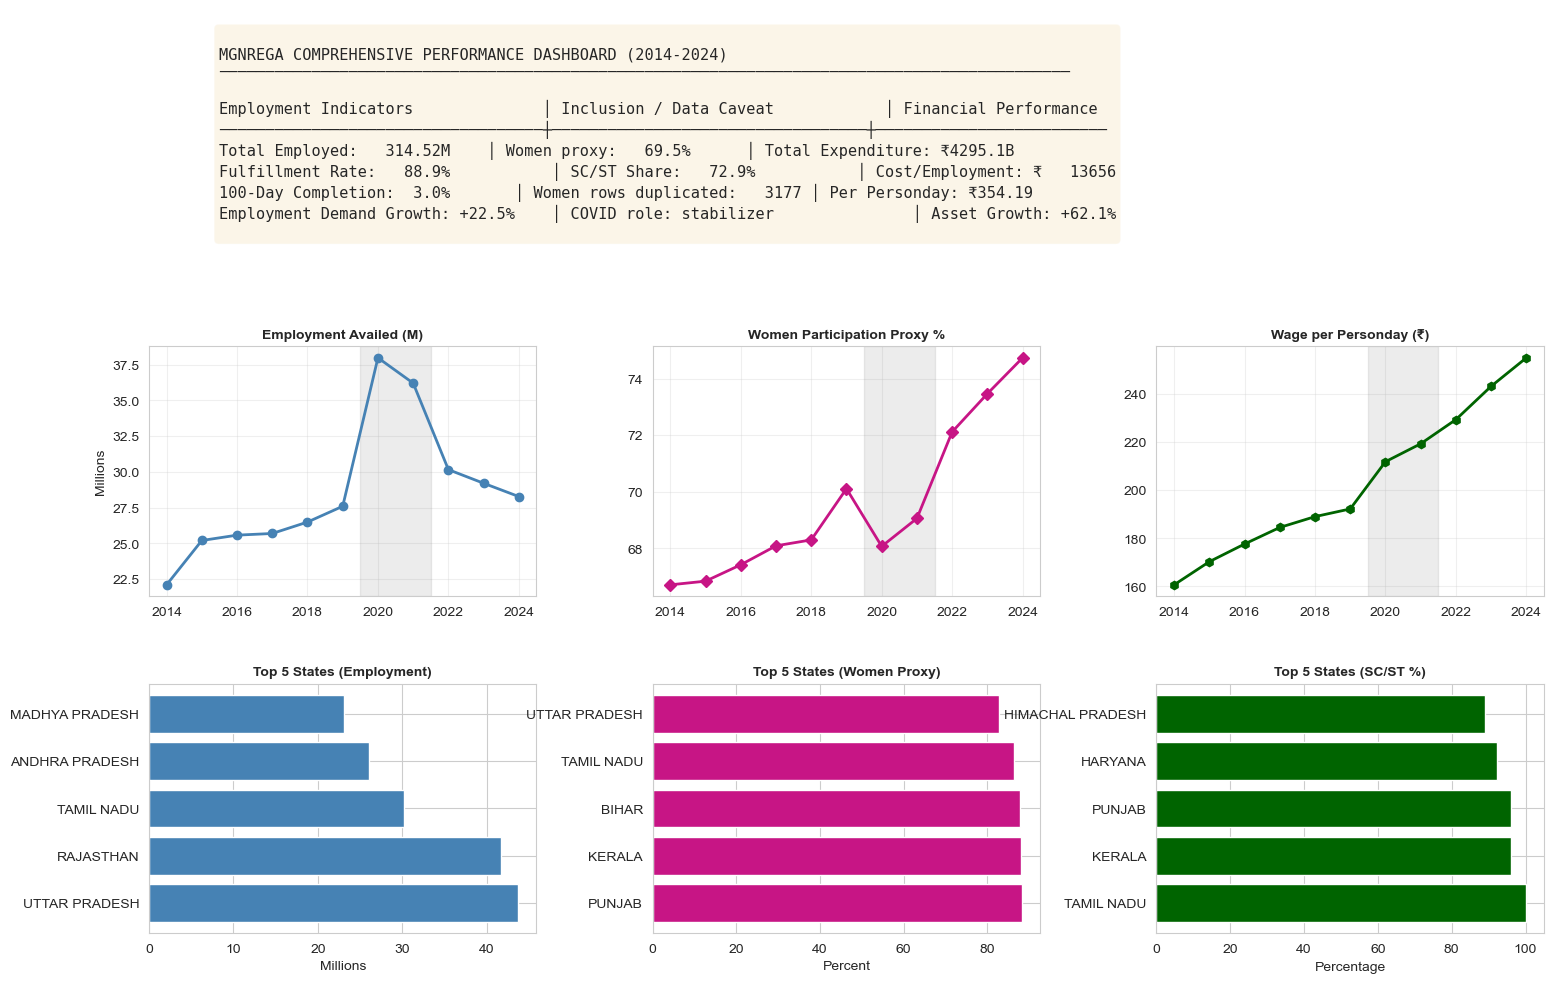


✓ Comprehensive dashboard saved


In [21]:
# Final Comprehensive Dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Key Metrics Summary
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')

summary_text = f"""
MGNREGA COMPREHENSIVE PERFORMANCE DASHBOARD (2014-2024)
────────────────────────────────────────────────────────────────────────────────────────────

Employment Indicators              │ Inclusion / Data Caveat            │ Financial Performance
───────────────────────────────────┼──────────────────────────────────┼─────────────────────────
Total Employed: {total_employment_provided/1e6:>8.2f}M    │ Women proxy: {(total_women_proxy/total_persons_employed*100):>6.1f}%      │ Total Expenditure: ₹{total_expenditure/1e9:>6.1f}B
Fulfillment Rate: {avg_fulfillment:>6.1f}%           │ SC/ST Share: {scst_share:>6.1f}%           │ Cost/Employment: ₹{(total_expenditure/total_employment_provided):>8.0f}
100-Day Completion: {hh_100day_avg:>4.1f}%       │ Women rows duplicated: {women_metric_equal_availed_rows:>6d} │ Per Personday: ₹{(financial_analysis.loc[financial_analysis['Year']==2024, 'Derived_Cost_Per_Personday'].values[0]):>6.2f}
Employment Demand Growth: +{((yearly_stats.loc[yearly_stats['Year']==2024, 'Employment_Demanded'].values[0] / yearly_stats.loc[yearly_stats['Year']==2014, 'Employment_Demanded'].values[0] - 1) * 100):.1f}%    │ COVID role: stabilizer               │ Asset Growth: +{asset_growth:.1f}%
"""

ax1.text(0.05, 0.5, summary_text, transform=ax1.transAxes, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 2-4. Mini timeseries
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(yearly_stats['Year'], yearly_stats['Employment_Availed']/1e6, marker='o', color='steelblue', linewidth=2)
ax2.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax2.set_title('Employment Availed (M)', fontweight='bold', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('Millions')

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(yearly_stats['Year'], yearly_stats['Women_Participation_Proxy'], marker='D', color='mediumvioletred', linewidth=2)
ax3.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax3.set_title('Women Participation Proxy %', fontweight='bold', fontsize=10)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(yearly_stats['Year'], yearly_stats['Avg_Wage_Per_Personday'], marker='h', color='darkgreen', linewidth=2)
ax4.axvspan(2019.5, 2021.5, color='grey', alpha=0.15)
ax4.set_title('Wage per Personday (₹)', fontweight='bold', fontsize=10)
ax4.grid(True, alpha=0.3)

# 5-7. State performance
ax5 = fig.add_subplot(gs[2, 0])
top5_states = state_analysis.nlargest(5, 'Employment_Availed')
ax5.barh(top5_states['State'], top5_states['Employment_Availed']/1e6, color='steelblue')
ax5.set_title('Top 5 States (Employment)', fontweight='bold', fontsize=10)
ax5.set_xlabel('Millions')

ax6 = fig.add_subplot(gs[2, 1])
women_top5 = state_analysis.nlargest(5, 'Women_Participation_Proxy')
ax6.barh(women_top5['State'], women_top5['Women_Participation_Proxy'], color='mediumvioletred')
ax6.set_title('Top 5 States (Women Proxy)', fontweight='bold', fontsize=10)
ax6.set_xlabel('Percent')

ax7 = fig.add_subplot(gs[2, 2])
scst_top5 = state_analysis.nlargest(5, 'SC_ST_Share')
ax7.barh(scst_top5['State'], scst_top5['SC_ST_Share'], color='darkgreen')
ax7.set_title('Top 5 States (SC/ST %)', fontweight='bold', fontsize=10)
ax7.set_xlabel('Percentage')

plt.savefig('07_Comprehensive_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive dashboard saved")

In [22]:
print("\n" + "="*80)
print("12. CONCLUSION & RESEARCH IMPLICATIONS")
print("="*80 + "\n")

conclusion = """
EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────────────

The Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA) represents 
one of the world's largest demand-driven employment guarantee schemes. This 
analysis of 11 years of panel data (2014-2024) covering {} states and {} districts 
reveals a complex picture of significant achievements tempered by implementation challenges.

KEY FINDINGS
─────────────

1. SCALE & REACH: The scheme employed an average of {:.1f} million people annually,
   with total cumulative employment of {:.1f} million person-years. This demonstrates
   the program's critical role in rural economic security.

2. COVID STABILIZATION ROLE: During 2020-2021, employment demand rose sharply above
   pre-COVID baseline, indicating MGNREGA's counter-cyclical role as a rural labor
   market stabilizer during systemic shocks.

3. WOMEN PARTICIPATION SECTION RESTORED AS PROXY: The proxy estimate is {:.1f}%, but
   {:.1f}% of rows have Women_Employment_Provided equal to Employment_Availed. Hence,
   this should be interpreted as directional evidence, not definitive gender inclusion.

4. SOCIAL EQUITY: Validated SC/ST workers form {:.1f}% of beneficiaries after capping
   inconsistent rows where subgroup counts exceed total employment. This still indicates
   strong inclusion of historically marginalized groups.

5. EMPLOYMENT SECURITY GAP: Despite strong provision, only {:.1f}% of households complete
   the guaranteed 100 days of employment. This suggests seasonal bottlenecks and the need
   for demand creation across agricultural calendars.

6. WAGE PROGRESSION: Real wages grew {:.1f}% from 2014 to 2024, indicating the scheme's
   role in supporting rural income growth.

7. FINANCIAL UNIT CORRECTION: Total_Expenditure is recorded in lakh rupees, not rupees.
   After correcting units, cumulative expenditure is ₹{:.1f} billion.

8. REGIONAL DISPARITIES: Significant variation exists across states in fulfillment
   rates (range: {:.1f}% to {:.1f}%), suggesting differential implementation capacity
   and demand patterns.

ECONOMIC POLICY IMPLICATIONS
────────────────────────────

FOR MACRO-RURAL STABILIZATION:
  1. Treat MGNREGA as an automatic stabilizer during labor-demand shocks
  2. Build trigger-based budget augmentation for crisis years
  3. Monitor demand spikes as early-warning signals of rural distress

FOR SOCIAL PROTECTION DESIGN:
  1. Improve 100-day completion through calendar redesign and project continuity
  2. Preserve SC/ST inclusion performance while improving work quality metrics
  3. Use women proxy with caution and procure verified gender fields for policy targeting

FOR FISCAL GOVERNANCE:
  1. Standardize expenditure units at source and in reporting pipelines
  2. Track derived cost-per-personday and cost-per-employment routinely
  3. Benchmark state-level efficiency and fulfillment gaps for budget incentives

FINAL ASSESSMENT:
MGNREGA has achieved strong scale, inclusion, and crisis buffering outcomes. For
policy-grade inference, the women metric should be treated as a proxy with caveats,
while expenditure and subgroup validations must remain embedded in the analysis pipeline.

Analysis Date: March 2026
Data Coverage: 2014-2024 (Panel Data)
Districts Analyzed: {}
States Covered: {}
Total Observations: {}

""".format(
    df['State'].nunique(),
    df['District'].nunique(),
    yearly_stats['Persons_Employed'].mean()/1e6,
    total_employment_provided/1e6,
    (total_women_proxy/total_persons_employed*100),
    women_metric_equal_availed_rows / len(df) * 100,
    scst_share,
    hh_100day_avg,
    wage_growth_actual,
    total_expenditure/1e9,
    state_perf['Fulfillment'].max(),
    state_perf['Fulfillment'].min(),
    df['District'].nunique(),
    df['State'].nunique(),
    len(df)
)

print(conclusion)

print("\n" + "="*80)
print("ALL VISUALIZATIONS SAVED:")
print("="*80)
print("""
✓ 01_Temporal_Trends.png              - Employment, fulfillment, women proxy, wages, COVID highlight
✓ 02_Geographic_Analysis.png          - State-level performance with women proxy
✓ 03_Employment_Quality_Inclusivity.png - Women proxy, SC/ST, duration, completion, COVID highlight
✓ 04_Financial_Analysis.png           - Expenditure, wages, and cost efficiency
✓ 05_Social_Indicators_Impact.png     - Poverty, income, agriculture, assets
✓ 06_Correlation_Analysis.png         - Variable relationships and district variability
✓ 07_Comprehensive_Dashboard.png      - Summary of key metrics and top performers

ANALYSIS COMPLETE!
═══════════════════════════════════════════════════════════════════════════════
""")


12. CONCLUSION & RESEARCH IMPLICATIONS


EXECUTIVE SUMMARY
──────────────────────────────────────────────────────────────────────────────

The Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA) represents 
one of the world's largest demand-driven employment guarantee schemes. This 
analysis of 11 years of panel data (2014-2024) covering 21 states and 293 districts 
reveals a complex picture of significant achievements tempered by implementation challenges.

KEY FINDINGS
─────────────

1. SCALE & REACH: The scheme employed an average of 41.1 million people annually,
   with total cumulative employment of 314.5 million person-years. This demonstrates
   the program's critical role in rural economic security.

2. COVID STABILIZATION ROLE: During 2020-2021, employment demand rose sharply above
   pre-COVID baseline, indicating MGNREGA's counter-cyclical role as a rural labor
   market stabilizer during systemic shocks.

3. WOMEN PARTICIPATION SECTION RESTORED AS PROXY: The p

In [23]:
# Audit of women and expenditure metrics
print("\n" + "="*80)
print("AUDIT: WOMEN & EXPENDITURE METRICS")
print("="*80 + "\n")

women_audit = pd.DataFrame({
    'rows_equal_availed': [(df['Women_Employment_Provided'] == df['Employment_Availed']).sum()],
    'rows_equal_persons': [(df['Women_Employment_Provided'] == df['Persons_Employed']).sum()],
    'rows_gt_availed': [(df['Women_Employment_Provided'] > df['Employment_Availed']).sum()],
    'rows_gt_persons': [(df['Women_Employment_Provided'] > df['Persons_Employed']).sum()],
    'corr_with_availed': [df['Women_Employment_Provided'].corr(df['Employment_Availed'])],
    'corr_with_persons': [df['Women_Employment_Provided'].corr(df['Persons_Employed'])]
})
print("Women metric audit:")
print(women_audit.T)

print("\nSample rows for women metric:")
print(df[['District','State','Year','Employment_Availed','Persons_Employed','Women_Employment_Provided']].head(15).to_string(index=False))

exp_audit = df[['Total_Expenditure','Total_Persondays','Avg_Wage_Per_Personday','Cost_Per_Personday']].copy()
exp_audit['Implied_Wage_Bill_Rupees'] = exp_audit['Total_Persondays'] * exp_audit['Avg_Wage_Per_Personday']
exp_audit['Implied_Total_Cost_Rupees'] = exp_audit['Total_Persondays'] * exp_audit['Cost_Per_Personday']
exp_audit['Expenditure_if_Rupees_ratio'] = exp_audit['Total_Expenditure'] / exp_audit['Implied_Total_Cost_Rupees']
exp_audit['Expenditure_if_LakhRupees_ratio'] = (exp_audit['Total_Expenditure'] * 100000) / exp_audit['Implied_Total_Cost_Rupees']

print("\nExpenditure unit audit:")
print(exp_audit[['Expenditure_if_Rupees_ratio','Expenditure_if_LakhRupees_ratio']].describe().round(4))

print("\nSample expenditure rows:")
sample_exp = df[['District','State','Year','Total_Expenditure','Total_Persondays','Avg_Wage_Per_Personday','Cost_Per_Personday']].head(10).copy()
sample_exp['Implied_Total_Cost_Rupees'] = sample_exp['Total_Persondays'] * sample_exp['Cost_Per_Personday']
sample_exp['Total_Expenditure_in_Rupees_if_Lakh'] = sample_exp['Total_Expenditure'] * 100000
print(sample_exp.to_string(index=False))


AUDIT: WOMEN & EXPENDITURE METRICS

Women metric audit:
                              0
rows_equal_availed  3177.000000
rows_equal_persons    17.000000
rows_gt_availed        5.000000
rows_gt_persons        0.000000
corr_with_availed      0.999981
corr_with_persons      0.961546

Sample rows for women metric:
District         State  Year  Employment_Availed  Persons_Employed  Women_Employment_Provided
ADILABAD     TELANGANA  2014              280593            525708                   280593.0
ADILABAD     TELANGANA  2015              299747            559369                   299747.0
ADILABAD     TELANGANA  2016               79765            152455                    79765.0
ADILABAD     TELANGANA  2017               71569            136136                    71569.0
ADILABAD     TELANGANA  2018               74113            139671                    74113.0
ADILABAD     TELANGANA  2019               73490            136040                    73490.0
ADILABAD     TELANGANA  2020  